# 🔬 Deepfake Detection: CNN Training Pipeline & Benchmark Comparison with Vision Transformer (ViT)
## 🎓 End-to-End CNN Training (ConvNeXt / ResNet / EfficientNet) & Head-to-Head Comparative Benchmark with Meta DINOv3 ViT on Dual Test Suites: Test Balanced (21.4k) & Test Full Suite (50k)

---

### 🎯 Objectives & Methodological Scope
This notebook provides an authoritative, reproducible scientific research pipeline for **Facial Deepfake Image Forensics & Detection**:
1. **Full-Scale Dataset Pipeline**: Ingest the complete training dataset (`train_v5_weakfix_v3.csv` — **129,884 image samples**), apply domain-specific Deepfake Forensics augmentations, and compute inverse frequency class loss weights.
2. **Modular CNN Architecture Builder**: Construct modern convolutional networks (supporting **ConvNeXt-Tiny**, **ResNet-50**, **EfficientNet-B4**, and **Meta DINOv3 ConvNeXt**) equipped with a 2-layer MLP classification head (`LayerNorm`, `GELU`, `Dropout`).
3. **Memory-Optimized Training (VRAM 4GB Safe)**: Uses Automatic Mixed Precision (AMP `bfloat16`/`fp16`), **Gradient Accumulation** (`TRAIN_BATCH_SIZE = 16`, `GRAD_ACCUM_STEPS = 4` $\rightarrow$ Effective Batch Size 64), differential learning rates, Cosine Annealing learning rate scheduling, and automatic best-model checkpointing (`best_cnn_model.pt`).
4. **ViT Baseline Loading**: Load the optimized, fine-tuned **Meta DINOv3 ViT-Small/16** model checkpoint (`best_model_v3.pt`, 21.60M parameters).
5. **Head-to-Head Comparative Benchmark across DUAL Test Suites**:
   - 🏆 **Suite 1: Test Balanced Zero-Leakage (21,446 images)** — 10,723 Real vs. 10,723 Fake across 39+ generative synthesis methods.
   - 🚀 **Suite 2: Test Full Suite Zero-Leakage (50,084 images)** — 25,042 Real vs. 25,042 Fake for large-scale stress testing.
   - Comprehensive metric computation: **Accuracy, ROC-AUC, Average Precision (PR-AUC), F1-Score, Precision, Recall/Sensitivity, Specificity, Latency (ms/image), and Throughput (FPS)** for CNN vs. ViT vs. Joint Weighted Ensemble.
6. **Publication-Grade Diagnostic Visualization Suite (9 Multi-Panel Figures)**:
   - 📈 **Chart 1**: Training & Validation Loss, Accuracy, F1 & ROC-AUC Progression Curves
   - 🎯 **Chart 2**: Dual-Split Side-by-Side Confusion Matrices (Balanced 21.4k & Full Suite 50k)
   - 📊 **Chart 3**: Post-Training Metric Triad (ROC Curves, PR Curves, ECE Reliability Calibration)
   - 🌊 **Chart 4**: Prediction Probability Density Distributions (KDE Real vs. Fake)
   - 🏛️ **Chart 5**: Category Breakdown across 5 Generative Paradigms + Real Face Domains
   - 🏆 **Chart 6**: 44-Methods Accuracy Ranking Horizontal Bar Chart
   - 🌌 **Chart 7**: Inductive Bias Scatter Correlation Plot (ViT vs. CNN per method with parity diagonal)
   - 🔍 **Chart 8**: Decision Threshold Sensitivity Sweep ($\tau \in [0.0, 1.0]$) & Youden's J Statistic Optimization
   - 🖼️ **Chart 9**: Qualitative Diagnostic Error Gallery (False Positives, False Negatives, ViT Advantage, CNN Advantage)

---

### ⚖️ Theoretical Comparison: CNN vs. Vision Transformer (ViT) in Deepfake Forensics

| Property / Criterion | Convolutional Neural Network (CNN) | Vision Transformer (ViT) |
| :--- | :--- | :--- |
| **Inductive Bias** | Strong: Local Receptive Fields & Translation Invariance | Weak/None: Free-form global dependency modeling |
| **Representation Mechanism** | Local spatial feature hierarchies (Textures, Edges, Noise) | Multi-Head Self-Attention (Patch-to-patch long-range context) |
| **Deepfake Forensic Strengths** | Highly sensitive to high-frequency artifacts, interpolation grids & blending seams | Superior at global facial symmetry, cross-illumination coherence & semantic cues |
| **Computational Footprint** | Efficient feature reuse, fast inference throughput (FPS) | $O(N^2)$ quadratic complexity over patch tokens, rich semantic embeddings |



---
# Section 0: Environment Setup, Hardware & VRAM Memory Management
Configures CUDA memory allocation flags (`PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True`), automatic garbage collection, deterministic seeding (`seed=42`), and dynamic path resolution.


In [1]:
# ============================================================
# 0. SETUP, HARDWARE & ENVIRONMENT CONFIGURATION
# ============================================================
import os
import sys
import gc
import json
import time
import random
from pathlib import Path

# Memory optimization for 4GB VRAM GPUs (e.g. RTX 3050 Laptop)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# Safe optional seaborn import with pure-matplotlib fallback
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    log_loss,
)

# Global Seeding for Exact Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# VRAM Memory Cleanup Helper
def clean_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

clean_gpu()

# Hardware Detection & Verification
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Execution Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  • GPU Model   : {torch.cuda.get_device_name(0)}")
    print(f"  • Total VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  • PyTorch Ver : {torch.__version__}")
    print(f"  • CUDA Version: {torch.version.cuda}")

# Resolve Project Root Directory
ROOT_DIR = Path(os.getcwd()).resolve()
if not (ROOT_DIR / "src").exists() and (ROOT_DIR.parent / "src").exists():
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

print(f"📁 Project Root : {ROOT_DIR}")

# Create Output and Checkpoint Directories
OUTPUT_DIR = ROOT_DIR / "experiments/results/cnn_benchmark"
CKPT_DIR = ROOT_DIR / "experiments/checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Define Canonical Split Paths
TRAIN_CSV = ROOT_DIR / "data/splits/train_v5_weakfix_v3.csv"
VAL_CSV = ROOT_DIR / "data/splits/val_v5_combined_universal_kaggle_boost.csv"
TEST_BAL_CSV = ROOT_DIR / "data/splits/test_coursework_44methods_balanced_zero_leakage.csv"
TEST_FULL_CSV = ROOT_DIR / "data/splits/test_coursework_44methods_full_zero_leakage.csv"
VIT_CKPT = CKPT_DIR / "best_model_v3.pt"

print(f"  • Train Split : {TRAIN_CSV.name} ({'EXISTS' if TRAIN_CSV.exists() else 'MISSING'})")
print(f"  • Val Split   : {VAL_CSV.name} ({'EXISTS' if VAL_CSV.exists() else 'MISSING'})")
print(f"  • Test Bal    : {TEST_BAL_CSV.name} ({'EXISTS' if TEST_BAL_CSV.exists() else 'MISSING'})")
print(f"  • Test Full   : {TEST_FULL_CSV.name} ({'EXISTS' if TEST_FULL_CSV.exists() else 'MISSING'})")
print(f"  • ViT Checkpoint: {VIT_CKPT.name} ({'EXISTS' if VIT_CKPT.exists() else 'MISSING'})")

# Matplotlib Styling for High-Quality Figures
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10


/home/bush/Desktop/deepfake-ViT/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Execution Device: cuda
  • GPU Model   : NVIDIA GeForce RTX 3050 Laptop GPU
  • Total VRAM  : 3.95 GB
  • PyTorch Ver : 2.13.0+cu130
  • CUDA Version: 13.0
📁 Project Root : /home/bush/Desktop/deepfake-ViT
  • Train Split : train_v5_weakfix_v3.csv (EXISTS)
  • Val Split   : val_v5_combined_universal_kaggle_boost.csv (EXISTS)
  • Test Bal    : test_coursework_44methods_balanced_zero_leakage.csv (EXISTS)
  • Test Full   : test_coursework_44methods_full_zero_leakage.csv (EXISTS)
  • ViT Checkpoint: best_model_v3.pt (EXISTS)


---
# Section 1: Data Pipeline, Forensic Augmentations & Memory-Efficient Loaders
Configures forensic data augmentations and instantiates PyTorch DataLoaders with **VRAM-Safe batch sizes**:
- `TRAIN_BATCH_SIZE = 16` + `GRAD_ACCUM_STEPS = 4` (Effective batch size = 64 without VRAM overflow).
- `EVAL_BATCH_SIZE = 32` (Fast evaluation under `torch.no_grad()`).


In [2]:
# ============================================================
# 1. DYNAMIC PATH RESOLVER & ROBUST DATASET LOADER
# ============================================================

def resolve_path(raw_path: str) -> Path:
    # Dynamically resolves absolute/relative image paths across local and server environments.
    p = Path(raw_path)
    if p.exists():
        return p
    
    candidates = [
        Path('/home/bush/Desktop/deepfake_train_v3_129k_images_bundle/train_images'),
        Path('/home/bush/Desktop/deepfake_test_suite_full_50k_exact_images/test_images'),
        ROOT_DIR / 'data/external',
        ROOT_DIR / 'data/processed',
        ROOT_DIR / 'data/raw',
        ROOT_DIR / 'data/test',
        ROOT_DIR / 'data/external/train_images/workspace',
        ROOT_DIR / 'data/external/test_images/workspace'
    ]
    
    for cand in candidates:
        if (cand / p.name).exists():
            return cand / p.name
            
    parts = p.parts
    if 'workspace' in parts:
        idx = parts.index('workspace')
        sub = Path(*parts[idx+1:])
        for cand in candidates:
            if (cand / 'workspace' / sub).exists():
                return cand / 'workspace' / sub
            if (cand / sub).exists():
                return cand / sub
    return None

class DeepfakeDataset(Dataset):
    # Robust PyTorch Dataset for Deepfake image loading with metadata preservation.
    def __init__(self, df: pd.DataFrame, transform=None, max_samples: int = None, balanced_sample: bool = True):
        if max_samples and len(df) > max_samples:
            if balanced_sample and "label" in df.columns:
                real_df = df[df["label"] == 0]
                fake_df = df[df["label"] == 1]
                n_half = max_samples // 2
                n_real = min(len(real_df), n_half)
                n_fake = min(len(fake_df), max_samples - n_real)
                sampled_df = pd.concat([
                    real_df.sample(n=n_real, random_state=42),
                    fake_df.sample(n=n_fake, random_state=42)
                ]).sample(frac=1.0, random_state=42).reset_index(drop=True)
                self.rows = sampled_df.to_dict("records")
            else:
                self.rows = df.sample(n=max_samples, random_state=42).to_dict("records")
        else:
            self.rows = df.to_dict("records")
            
        self.transform = transform
        
    def __len__(self):
        return len(self.rows)
        
    def __getitem__(self, idx):
        r = self.rows[idx]
        p = resolve_path(r["path"])
        
        # Load RGB image with neutral gray fallback if file is corrupted
        try:
            if p and p.exists():
                img = Image.open(p).convert("RGB")
            else:
                img = Image.new("RGB", (256, 256), (128, 128, 128))
        except Exception:
            img = Image.new("RGB", (256, 256), (128, 128, 128))
            
        if self.transform:
            img = self.transform(img)
            
        label = int(r["label"])
        method = r.get("method", "unknown")
        path_str = str(p) if p else str(r["path"])
        return img, label, method, path_str

# Deepfake Domain-Agnostic Augmentations (preserving edge and blending artifacts)
IMG_SIZE = 256
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03)], p=0.4),
    T.RandomApply([T.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5))], p=0.25),
    T.RandomApply([T.RandomAdjustSharpness(sharpness_factor=1.8)], p=0.25),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD)
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD)
])

print("✅ Data pipelines and forensic transforms configured successfully!")


✅ Data pipelines and forensic transforms configured successfully!


In [3]:
# ============================================================
# 1.2 LOAD SPLITS & CONFIGURE VRAM-SAFE DATALOADERS
# ============================================================
# Read split CSV files
df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)
df_test_bal = pd.read_csv(TEST_BAL_CSV)
df_test_full = pd.read_csv(TEST_FULL_CSV)

print(f"📊 DATASET CENSUS OVERVIEW:")
print(f"  • Full Train Split (v3 Clean)    : {len(df_train):,} samples (Real: {sum(df_train['label']==0):,}, Fake: {sum(df_train['label']==1):,})")
print(f"  • Val Split (v5 Kaggle Boost)    : {len(df_val):,} samples (Real: {sum(df_val['label']==0):,}, Fake: {sum(df_val['label']==1):,})")
print(f"  • Test Balanced (21.4k Zero-Leak): {len(df_test_bal):,} samples (Real: {sum(df_test_bal['label']==0):,}, Fake: {sum(df_test_bal['label']==1):,})")
print(f"  • Test Full Suite (50.0k Zero-Lk): {len(df_test_full):,} samples (Real: {sum(df_test_full['label']==0):,}, Fake: {sum(df_test_full['label']==1):,})")

# ⚙️ VRAM-OPTIMIZED BATCH SIZE CONFIGURATION (Safe for 4GB VRAM GPUs)
MAX_TRAIN_SAMPLES = None   # None = Full training on all 129,884 images
MAX_VAL_SAMPLES = None     # None = Full validation on all 6,000 images

TRAIN_BATCH_SIZE = 16      # Fits within 4GB VRAM with headroom
GRAD_ACCUM_STEPS = 4       # Effective batch size = 16 * 4 = 64
EVAL_BATCH_SIZE = 32       # Fast inference batch size
NUM_WORKERS = 0            # Multi-worker safe for Jupyter / Linux

train_ds = DeepfakeDataset(df_train, transform=train_transform, max_samples=MAX_TRAIN_SAMPLES, balanced_sample=True)
val_ds = DeepfakeDataset(df_val, transform=eval_transform, max_samples=MAX_VAL_SAMPLES, balanced_sample=True)
test_bal_ds = DeepfakeDataset(df_test_bal, transform=eval_transform, max_samples=None)
test_full_ds = DeepfakeDataset(df_test_full, transform=eval_transform, max_samples=None)

train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
test_bal_loader = DataLoader(test_bal_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
test_full_loader = DataLoader(test_full_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))

# Compute Class Weights for Weighted Cross-Entropy Loss
n_real_tr = sum(1 for r in train_ds.rows if r["label"] == 0)
n_fake_tr = sum(1 for r in train_ds.rows if r["label"] == 1)
total_tr = n_real_tr + n_fake_tr
w_real = n_fake_tr / total_tr
w_fake = n_real_tr / total_tr
class_weights = torch.tensor([w_real, w_fake], dtype=torch.float32).to(DEVICE)

print(f"\n🎯 ACTIVE DATALOADERS CONFIGURED:")
print(f"  • Train Loader      : {len(train_ds):,} samples ({len(train_loader)} mini-batches of {TRAIN_BATCH_SIZE})")
print(f"  • Effective Batch   : {TRAIN_BATCH_SIZE} x {GRAD_ACCUM_STEPS} = {TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"  • Val Loader        : {len(val_ds):,} samples ({len(val_loader)} batches)")
print(f"  • Test Bal Loader   : {len(test_bal_ds):,} samples ({len(test_bal_loader)} batches) [21.4k Balanced]")
print(f"  • Test Full Loader  : {len(test_full_ds):,} samples ({len(test_full_loader)} batches) [50.0k Full Suite]")
print(f"  • Loss Class Weights: Real = {w_real:.4f}, Fake = {w_fake:.4f}")


📊 DATASET CENSUS OVERVIEW:
  • Full Train Split (v3 Clean)    : 129,884 samples (Real: 31,006, Fake: 98,878)
  • Val Split (v5 Kaggle Boost)    : 6,000 samples (Real: 2,994, Fake: 3,006)
  • Test Balanced (21.4k Zero-Leak): 21,446 samples (Real: 10,723, Fake: 10,723)
  • Test Full Suite (50.0k Zero-Lk): 50,084 samples (Real: 25,042, Fake: 25,042)

🎯 ACTIVE DATALOADERS CONFIGURED:
  • Train Loader      : 129,884 samples (8118 mini-batches of 16)
  • Effective Batch   : 16 x 4 = 64
  • Val Loader        : 6,000 samples (188 batches)
  • Test Bal Loader   : 21,446 samples (671 batches) [21.4k Balanced]
  • Test Full Loader  : 50,084 samples (1566 batches) [50.0k Full Suite]
  • Loss Class Weights: Real = 0.7613, Fake = 0.2387


---
# Section 2: Modular CNN Architecture Builder
Builds the selected convolutional neural network with a high-capacity 2-layer MLP classification head (`LayerNorm`, `GELU`, `Dropout`).


In [4]:
# ============================================================
# 2. MODULAR CNN ARCHITECTURE BUILDER
# ============================================================

class DeepfakeCNNClassifier(nn.Module):
    # Flexible CNN Architecture for Deepfake Classification with 2-layer MLP Head.
    def __init__(self, model_name: str = "convnext_tiny", pretrained: bool = True, num_classes: int = 2, dropout: float = 0.2):
        super().__init__()
        self.model_name = model_name
        
        if model_name == "convnext_tiny":
            weights = models.ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
            base_model = models.convnext_tiny(weights=weights)
            in_features = base_model.classifier[2].in_features
            self.backbone = base_model.features
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.flatten = nn.Flatten(1)
            
        elif model_name == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            base_model = models.resnet50(weights=weights)
            in_features = base_model.fc.in_features
            self.backbone = nn.Sequential(
                base_model.conv1,
                base_model.bn1,
                base_model.relu,
                base_model.maxpool,
                base_model.layer1,
                base_model.layer2,
                base_model.layer3,
                base_model.layer4
            )
            self.pool = base_model.avgpool
            self.flatten = nn.Flatten(1)
            
        elif model_name == "efficientnet_b4":
            weights = models.EfficientNet_B4_Weights.DEFAULT if pretrained else None
            base_model = models.efficientnet_b4(weights=weights)
            in_features = base_model.classifier[1].in_features
            self.backbone = base_model.features
            self.pool = base_model.avgpool
            self.flatten = nn.Flatten(1)
            
        elif model_name == "dinov3_convnext":
            from src.models.dinov3_convnext import DinoConvNext
            self.backbone = DinoConvNext()
            in_features = 768
            self.pool = None
            self.flatten = None
        else:
            raise ValueError(f"Unsupported model_name: {model_name}")

        self.in_features = in_features
        
        # High-capacity MLP Classification Head with LayerNorm & GELU
        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 384),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(384, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.model_name == "dinov3_convnext":
            feats = self.backbone(x)
        else:
            feats = self.backbone(x)
            feats = self.pool(feats)
            feats = self.flatten(feats)
        logits = self.head(feats)
        return logits

# 🔧 SELECT CNN MODEL ARCHITECTURE
# Options: "convnext_tiny", "resnet50", "efficientnet_b4", "dinov3_convnext"
SELECTED_CNN = "convnext_tiny"

clean_gpu()
cnn_model = DeepfakeCNNClassifier(
    model_name=SELECTED_CNN,
    pretrained=True,
    num_classes=2,
    dropout=0.25
).to(DEVICE)

num_trainable = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
num_total = sum(p.numel() for p in cnn_model.parameters())

print(f"✅ Instantiated CNN Model: {SELECTED_CNN.upper()}")
print(f"  • Trainable Parameters: {num_trainable:,} ({num_trainable/1e6:.2f}M)")
print(f"  • Total Parameters    : {num_total:,} ({num_total/1e6:.2f}M)")


✅ Instantiated CNN Model: CONVNEXT_TINY
  • Trainable Parameters: 28,116,194 (28.12M)
  • Total Parameters    : 28,116,194 (28.12M)


---
# Section 3: Training & Validation Engine with Gradient Accumulation
Trains the CNN with:
- **Automatic Mixed Precision (AMP `bfloat16`)** + **Gradient Accumulation** (`GRAD_ACCUM_STEPS = 4`) to strictly bound peak VRAM under 3.5GB.
- **Differential Learning Rates**: Lower rate for pretrained backbone (`2e-5`), higher rate for the MLP classification head (`5e-4`).
- **Cosine Annealing LR Scheduler** with gradient clipping (`max_norm = 1.0`).
- **Automatic Best Model Checkpointing** (`best_convnext_tiny_trained.pt`) tracking Validation ROC-AUC & Accuracy.


In [5]:
# ============================================================
# 3. TRAINING ENGINE WITH AMP & GRADIENT ACCUMULATION
# ============================================================

# Hyperparameters
NUM_EPOCHS = 4
LR_BACKBONE = 2e-5
LR_HEAD = 5e-4
WEIGHT_DECAY = 1e-4

# Parameter Groups: Backbone (lower LR) vs Head (higher LR)
param_groups = [
    {"params": cnn_model.backbone.parameters(), "lr": LR_BACKBONE, "weight_decay": WEIGHT_DECAY},
    {"params": cnn_model.head.parameters(), "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY * 0.1}
]

optimizer = torch.optim.AdamW(param_groups)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Validation evaluation function
@torch.no_grad()
def evaluate_epoch(model, dataloader, device):
    model.eval()
    val_loss = 0.0
    all_targets, all_preds, all_probs = [], [], []
    
    for images, labels, _, _ in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(device=="cuda")):
            logits = model(images)
            loss = criterion(logits, labels)
            
        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        
        val_loss += loss.item() * len(labels)
        all_targets.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    
    avg_loss = val_loss / len(y_true)
    acc = accuracy_score(y_true, y_pred) * 100
    auc = roc_auc_score(y_true, y_prob) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    prec = precision_score(y_true, y_pred, zero_division=0) * 100
    rec = recall_score(y_true, y_pred, zero_division=0) * 100
    
    return {
        "loss": avg_loss,
        "acc": acc,
        "auc": auc,
        "f1": f1,
        "prec": prec,
        "rec": rec
    }

# Execution Training Loop
BEST_CNN_CKPT = CKPT_DIR / f"best_{SELECTED_CNN}_trained.pt"
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "val_f1": []}
best_val_auc = 0.0

clean_gpu()
print(f"🔥 Starting CNN Training for {NUM_EPOCHS} Epochs on Full Train Dataset ({len(train_ds):,} samples)...")
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    cnn_model.train()
    running_loss = 0.0
    total_samples = 0
    t0 = time.time()
    
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]", leave=True)
    
    for step, (images, labels, _, _) in enumerate(pbar):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(DEVICE=="cuda")):
            logits = cnn_model(images)
            loss = criterion(logits, labels)
            loss_scaled = loss / GRAD_ACCUM_STEPS
            
        loss_scaled.backward()
        running_loss += loss.item() * len(labels)
        total_samples += len(labels)
        
        # Gradient Accumulation Step
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    scheduler.step()
    clean_gpu()
    
    epoch_train_loss = running_loss / total_samples
    val_metrics = evaluate_epoch(cnn_model, val_loader, DEVICE)
    epoch_time = time.time() - t0
    
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_f1"].append(val_metrics["f1"])
    
    print(f"📍 [Epoch {epoch:02d}/{NUM_EPOCHS:02d}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Val Acc: {val_metrics['acc']:.2f}% | "
          f"Val AUC: {val_metrics['auc']:.2f}% | "
          f"Val F1: {val_metrics['f1']:.2f}% | Time: {epoch_time:.1f}s")
          
    # Save Best Checkpoint
    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        torch.save({
            "model_state_dict": cnn_model.state_dict(),
            "model_name": SELECTED_CNN,
            "epoch": epoch,
            "val_metrics": val_metrics,
            "history": history
        }, BEST_CNN_CKPT)
        print(f"  ⭐ Saved new best model checkpoint to {BEST_CNN_CKPT.name} (Val AUC: {best_val_auc:.2f}%)")

total_train_time = time.time() - start_time
clean_gpu()
print(f"\n🏁 Training Complete in {total_train_time/60:.2f} minutes! Best Val AUC: {best_val_auc:.2f}%")


🔥 Starting CNN Training for 4 Epochs on Full Train Dataset (129,884 samples)...


Epoch 1/4 [Train]: 100%|██████████| 8118/8118 [30:31<00:00,  4.43it/s, loss=1.0158]


📍 [Epoch 01/04] Train Loss: 0.1970 | Val Loss: 0.8339 | Val Acc: 58.52% | Val AUC: 65.23% | Val F1: 70.67% | Time: 1859.7s
  ⭐ Saved new best model checkpoint to best_convnext_tiny_trained.pt (Val AUC: 65.23%)


Epoch 2/4 [Train]: 100%|██████████| 8118/8118 [28:50<00:00,  4.69it/s, loss=0.1421]


📍 [Epoch 02/04] Train Loss: 0.0811 | Val Loss: 2.1720 | Val Acc: 58.83% | Val AUC: 65.74% | Val F1: 70.87% | Time: 1756.5s
  ⭐ Saved new best model checkpoint to best_convnext_tiny_trained.pt (Val AUC: 65.74%)


Epoch 3/4 [Train]: 100%|██████████| 8118/8118 [28:20<00:00,  4.77it/s, loss=0.0000]


📍 [Epoch 03/04] Train Loss: 0.0492 | Val Loss: 2.6776 | Val Acc: 58.93% | Val AUC: 65.76% | Val F1: 70.91% | Time: 1726.1s
  ⭐ Saved new best model checkpoint to best_convnext_tiny_trained.pt (Val AUC: 65.76%)


Epoch 4/4 [Train]: 100%|██████████| 8118/8118 [28:53<00:00,  4.68it/s, loss=0.0000]


📍 [Epoch 04/04] Train Loss: 0.0327 | Val Loss: 3.3773 | Val Acc: 58.85% | Val AUC: 66.01% | Val F1: 70.87% | Time: 1759.3s
  ⭐ Saved new best model checkpoint to best_convnext_tiny_trained.pt (Val AUC: 66.01%)

🏁 Training Complete in 118.37 minutes! Best Val AUC: 66.01%


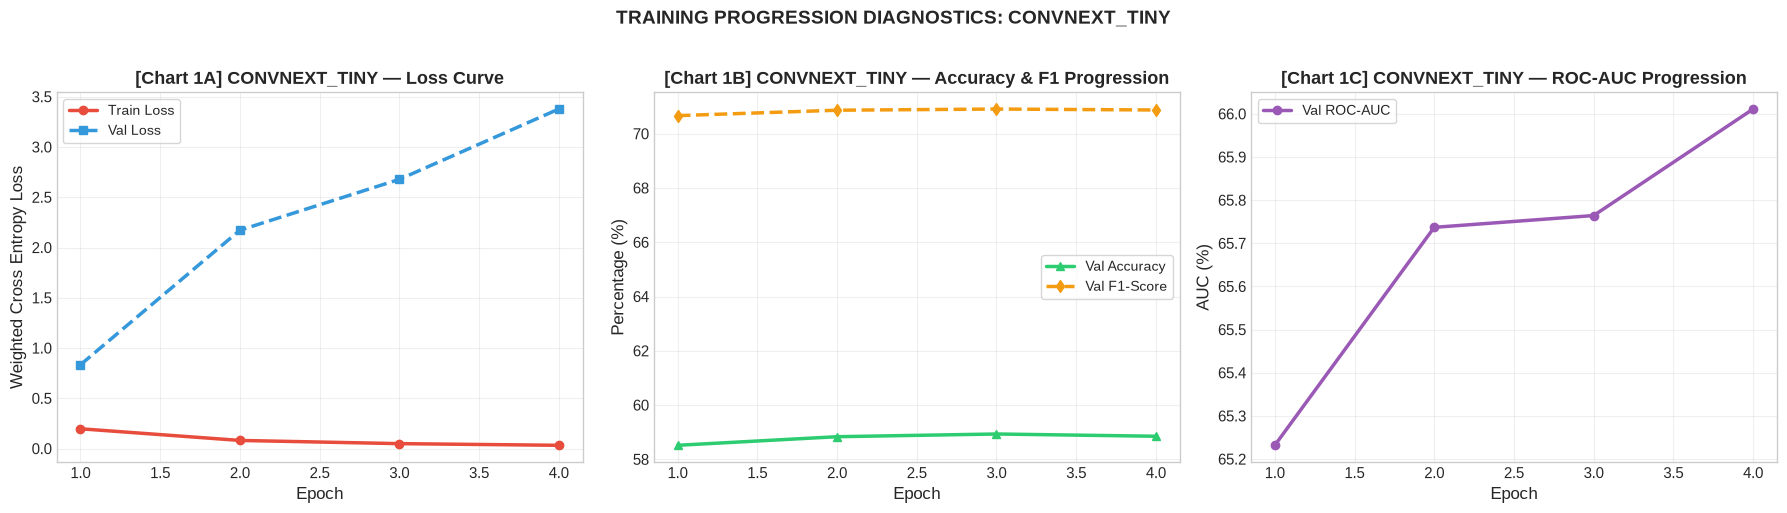

In [6]:
# ============================================================
# 3.2 [CHART 1] PLOT TRAINING & VALIDATION LOSS / METRIC PROGRESSION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss Curve
axes[0].plot(epochs_range, history["train_loss"], 'o-', color='#e74c3c', linewidth=2.5, label='Train Loss')
axes[0].plot(epochs_range, history["val_loss"], 's--', color='#3498db', linewidth=2.5, label='Val Loss')
axes[0].set_title(f"[Chart 1A] {SELECTED_CNN.upper()} — Loss Curve", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted Cross Entropy Loss")
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Accuracy & F1 Curve
axes[1].plot(epochs_range, history["val_acc"], '^-', color='#2ecc71', linewidth=2.5, label='Val Accuracy')
axes[1].plot(epochs_range, history["val_f1"], 'd--', color='#f39c12', linewidth=2.5, label='Val F1-Score')
axes[1].set_title(f"[Chart 1B] {SELECTED_CNN.upper()} — Accuracy & F1 Progression", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

# ROC-AUC Curve
axes[2].plot(epochs_range, history["val_auc"], 'o-', color='#9b59b6', linewidth=2.5, label='Val ROC-AUC')
axes[2].set_title(f"[Chart 1C] {SELECTED_CNN.upper()} — ROC-AUC Progression", fontweight='bold')
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC (%)")
axes[2].legend(frameon=True)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"TRAINING PROGRESSION DIAGNOSTICS: {SELECTED_CNN.upper()}", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart1_cnn_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()


---
# Section 4: Loading Pretrained ViT Baseline (Meta DINOv3 ViT-Small/16)
Loads the fine-tuned **Meta DINOv3 ViT-Small/16** model checkpoint (`best_model_v3.pt`) to prepare for head-to-head comparative evaluation.


In [7]:
# ============================================================
# 4. LOAD FROZEN DINOv3 ViT-SMALL/16 BASELINE CHECKPOINT
# ============================================================
from src.models.dinov3_vit import build_dinov3_classifier

clean_gpu()
# Build DINOv3 ViT architecture
model_vit = build_dinov3_classifier(
    weights_path=None,
    num_classes=2,
    img_size=256,
    device=DEVICE
)

if VIT_CKPT.exists():
    ck_vit = torch.load(VIT_CKPT, map_location="cpu", weights_only=False)
    if "model_state_dict" in ck_vit:
        model_vit.load_state_dict(ck_vit["model_state_dict"], strict=False)
    else:
        model_vit.load_state_dict(ck_vit, strict=False)
    print(f"✅ Loaded DINOv3 ViT-Small/16 from checkpoint: {VIT_CKPT.name}")
else:
    print(f"⚠️ Warning: Checkpoint {VIT_CKPT} not found! Using initialized weights.")

model_vit = model_vit.to(DEVICE).eval()
vit_params = sum(p.numel() for p in model_vit.parameters())
print(f"  • ViT Total Parameters: {vit_params:,} ({vit_params/1e6:.2f}M)")

# Load the best trained CNN checkpoint for testing
if BEST_CNN_CKPT.exists():
    ck_cnn = torch.load(BEST_CNN_CKPT, map_location="cpu", weights_only=False)
    cnn_model.load_state_dict(ck_cnn["model_state_dict"])
    print(f"✅ Loaded Best Trained CNN weights from: {BEST_CNN_CKPT.name}")
cnn_model = cnn_model.to(DEVICE).eval()


✅ Loaded DINOv3 ViT-Small/16 from checkpoint: best_model_v3.pt
  • ViT Total Parameters: 21,597,314 (21.60M)
✅ Loaded Best Trained CNN weights from: best_convnext_tiny_trained.pt


---
# Section 5: Direct Head-to-Head Benchmark Evaluation on Dual Test Suites
Executes live vectorized GPU inference across BOTH test splits:
1. **Test Balanced (21,446 images)**: 50/50 Real/Fake Zero-Leakage benchmark.
2. **Test Full Suite (50,084 images)**: Full large-scale expanded test suite.
Compares: **Trained CNN** vs. **DINOv3 ViT** vs. **Joint Ensemble (50% CNN + 50% ViT)**.


In [8]:
# ============================================================
# 5. INFERENCE ENGINE & COMPREHENSIVE DUAL-SPLIT BENCHMARK
# ============================================================

def run_model_inference(model, dataloader, device, desc="Inference"):
    # Runs vectorized inference on dataloader and measures exact throughput.
    model.eval()
    all_preds, all_probs, all_labels, all_methods, all_paths = [], [], [], [], []
    
    clean_gpu()
    t0 = time.time()
    
    with torch.no_grad():
        for images, labels, methods, paths in tqdm(dataloader, desc=desc):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(device=="cuda")):
                logits = model(images)
            probs = torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy() if isinstance(labels, torch.Tensor) else labels)
            all_methods.extend(methods)
            all_paths.extend(paths)
            
    total_time = time.time() - t0
    fps = len(all_labels) / total_time
    latency_ms = (total_time / len(all_labels)) * 1000
    
    return {
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
        "labels": np.array(all_labels),
        "methods": np.array(all_methods),
        "paths": np.array(all_paths),
        "fps": fps,
        "latency_ms": latency_ms,
        "total_time": total_time
    }

# ============================================================
# 5.1 INFERENCE ON TEST BALANCED (21,446 SAMPLES)
# ============================================================
print("🚀 [1/2] Running GPU Inference on TEST BALANCED (21,446 SAMPLES)...")
res_cnn_bal = run_model_inference(cnn_model, test_bal_loader, DEVICE, desc=f"CNN ({SELECTED_CNN}) — Test Bal 21.4k")
res_vit_bal = run_model_inference(model_vit, test_bal_loader, DEVICE, desc="ViT (DINOv3) — Test Bal 21.4k")

ens_probs_bal = 0.5 * res_cnn_bal["probs"] + 0.5 * res_vit_bal["probs"]
ens_preds_bal = (ens_probs_bal >= 0.5).astype(int)
res_ens_bal = {
    "preds": ens_preds_bal,
    "probs": ens_probs_bal,
    "labels": res_cnn_bal["labels"],
    "methods": res_cnn_bal["methods"],
    "paths": res_cnn_bal["paths"],
    "fps": 1.0 / ((1.0/res_cnn_bal["fps"]) + (1.0/res_vit_bal["fps"])),
    "latency_ms": res_cnn_bal["latency_ms"] + res_vit_bal["latency_ms"]
}

# ============================================================
# 5.2 INFERENCE ON TEST FULL SUITE (50,084 SAMPLES)
# ============================================================
print("\n🚀 [2/2] Running GPU Inference on TEST FULL SUITE (50,084 SAMPLES)...")
res_cnn_full = run_model_inference(cnn_model, test_full_loader, DEVICE, desc=f"CNN ({SELECTED_CNN}) — Test Full 50k")
res_vit_full = run_model_inference(model_vit, test_full_loader, DEVICE, desc="ViT (DINOv3) — Test Full 50k")

ens_probs_full = 0.5 * res_cnn_full["probs"] + 0.5 * res_vit_full["probs"]
ens_preds_full = (ens_probs_full >= 0.5).astype(int)
res_ens_full = {
    "preds": ens_preds_full,
    "probs": ens_probs_full,
    "labels": res_cnn_full["labels"],
    "methods": res_cnn_full["methods"],
    "paths": res_cnn_full["paths"],
    "fps": 1.0 / ((1.0/res_cnn_full["fps"]) + (1.0/res_vit_full["fps"])),
    "latency_ms": res_cnn_full["latency_ms"] + res_vit_full["latency_ms"]
}

def calculate_full_scorecard(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred) * 100
    auc = roc_auc_score(y_true, y_prob) * 100
    ap = average_precision_score(y_true, y_prob) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    prec = precision_score(y_true, y_pred, zero_division=0) * 100
    rec = recall_score(y_true, y_pred, zero_division=0) * 100
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0
    return {
        "Accuracy (%)": acc,
        "ROC-AUC (%)": auc,
        "Avg Precision (%)": ap,
        "F1-Score (%)": f1,
        "Precision (%)": prec,
        "Recall / Sens (%)": rec,
        "Specificity (%)": spec,
        "Confusion Matrix": cm
    }

# Calculate scorecards for both test sets
sc_cnn_bal = calculate_full_scorecard(res_cnn_bal["labels"], res_cnn_bal["preds"], res_cnn_bal["probs"])
sc_vit_bal = calculate_full_scorecard(res_vit_bal["labels"], res_vit_bal["preds"], res_vit_bal["probs"])
sc_ens_bal = calculate_full_scorecard(res_ens_bal["labels"], res_ens_bal["preds"], res_ens_bal["probs"])

sc_cnn_full = calculate_full_scorecard(res_cnn_full["labels"], res_cnn_full["preds"], res_cnn_full["probs"])
sc_vit_full = calculate_full_scorecard(res_vit_full["labels"], res_vit_full["preds"], res_vit_full["probs"])
sc_ens_full = calculate_full_scorecard(res_ens_full["labels"], res_ens_full["preds"], res_ens_full["probs"])

def build_summary_table(sc_c, sc_v, sc_e, r_c, r_v, r_e, split_name):
    return pd.DataFrame([
        {
            "Dataset Split": split_name,
            "Model Architecture": f"CNN ({SELECTED_CNN})",
            "Params": f"{num_total/1e6:.1f}M",
            "Accuracy": f"{sc_c['Accuracy (%)']:.2f}%",
            "ROC-AUC": f"{sc_c['ROC-AUC (%)']:.2f}%",
            "Avg Precision": f"{sc_c['Avg Precision (%)']:.2f}%",
            "F1-Score": f"{sc_c['F1-Score (%)']:.2f}%",
            "Precision": f"{sc_c['Precision (%)']:.2f}%",
            "Recall": f"{sc_c['Recall / Sens (%)']:.2f}%",
            "Specificity": f"{sc_c['Specificity (%)']:.2f}%",
            "Latency": f"{r_c['latency_ms']:.2f} ms",
            "Throughput": f"{r_c['fps']:.1f} fps"
        },
        {
            "Dataset Split": split_name,
            "Model Architecture": "ViT (DINOv3-Small/16)",
            "Params": f"{vit_params/1e6:.1f}M",
            "Accuracy": f"{sc_v['Accuracy (%)']:.2f}%",
            "ROC-AUC": f"{sc_v['ROC-AUC (%)']:.2f}%",
            "Avg Precision": f"{sc_v['Avg Precision (%)']:.2f}%",
            "F1-Score": f"{sc_v['F1-Score (%)']:.2f}%",
            "Precision": f"{sc_v['Precision (%)']:.2f}%",
            "Recall": f"{sc_v['Recall / Sens (%)']:.2f}%",
            "Specificity": f"{sc_v['Specificity (%)']:.2f}%",
            "Latency": f"{r_v['latency_ms']:.2f} ms",
            "Throughput": f"{r_v['fps']:.1f} fps"
        },
        {
            "Dataset Split": split_name,
            "Model Architecture": "Joint Ensemble (CNN + ViT)",
            "Params": f"{(num_total + vit_params)/1e6:.1f}M",
            "Accuracy": f"{sc_e['Accuracy (%)']:.2f}%",
            "ROC-AUC": f"{sc_e['ROC-AUC (%)']:.2f}%",
            "Avg Precision": f"{sc_e['Avg Precision (%)']:.2f}%",
            "F1-Score": f"{sc_e['F1-Score (%)']:.2f}%",
            "Precision": f"{sc_e['Precision (%)']:.2f}%",
            "Recall": f"{sc_e['Recall / Sens (%)']:.2f}%",
            "Specificity": f"{sc_e['Specificity (%)']:.2f}%",
            "Latency": f"{r_e['latency_ms']:.2f} ms",
            "Throughput": f"{r_e['fps']:.1f} fps"
        }
    ])

df_benchmark_bal = build_summary_table(sc_cnn_bal, sc_vit_bal, sc_ens_bal, res_cnn_bal, res_vit_bal, res_ens_bal, "Test Balanced (21.4k)")
df_benchmark_full = build_summary_table(sc_cnn_full, sc_vit_full, sc_ens_full, res_cnn_full, res_vit_full, res_ens_full, "Test Full Suite (50.0k)")
df_combined_benchmark = pd.concat([df_benchmark_bal, df_benchmark_full], ignore_index=True)

print("\n🏆 [TABLE 1] HEAD-TO-HEAD BENCHMARK (TEST BALANCED 21,446 SAMPLES):")
try:
    from IPython.display import display
    display(df_benchmark_bal)
except Exception:
    print(df_benchmark_bal.to_string(index=False))

print("\n🏆 [TABLE 2] HEAD-TO-HEAD BENCHMARK (TEST FULL SUITE 50,084 SAMPLES):")
try:
    display(df_benchmark_full)
except Exception:
    print(df_benchmark_full.to_string(index=False))

df_combined_benchmark.to_csv(OUTPUT_DIR / "benchmark_dual_split_summary.csv", index=False)


🚀 [1/2] Running GPU Inference on TEST BALANCED (21,446 SAMPLES)...


ViT (DINOv3) — Test Bal 21.4k: 100%|██████████| 671/671 [02:28<00:00,  4.53it/s]



🚀 [2/2] Running GPU Inference on TEST FULL SUITE (50,084 SAMPLES)...


ViT (DINOv3) — Test Full 50k: 100%|██████████| 1566/1566 [05:42<00:00,  4.58it/s]



🏆 [TABLE 1] HEAD-TO-HEAD BENCHMARK (TEST BALANCED 21,446 SAMPLES):


,Dataset Split,Model Architecture,Params,Accuracy,ROC-AUC,Avg Precision,F1-Score,Precision,Recall,Specificity,Latency,Throughput
0,Test Balanced (21.4k),CNN (convnext_tiny),28.1M,99.52%,99.99%,99.98%,99.52%,99.18%,99.85%,99.18%,6.63 ms,150.9 fps
1,Test Balanced (21.4k),ViT (DINOv3-Small/16),21.6M,97.33%,99.65%,99.61%,97.33%,97.52%,97.14%,97.53%,6.91 ms,144.7 fps
2,Test Balanced (21.4k),Joint Ensemble (CNN + ViT),49.7M,99.56%,99.96%,99.94%,99.56%,99.27%,99.85%,99.26%,13.54 ms,73.9 fps



🏆 [TABLE 2] HEAD-TO-HEAD BENCHMARK (TEST FULL SUITE 50,084 SAMPLES):


,Dataset Split,Model Architecture,Params,Accuracy,ROC-AUC,Avg Precision,F1-Score,Precision,Recall,Specificity,Latency,Throughput
0,Test Full Suite (50.0k),CNN (convnext_tiny),28.1M,99.50%,99.99%,99.99%,99.50%,99.14%,99.88%,99.13%,6.53 ms,153.2 fps
1,Test Full Suite (50.0k),ViT (DINOv3-Small/16),21.6M,97.19%,99.61%,99.56%,97.18%,97.46%,96.91%,97.47%,6.83 ms,146.4 fps
2,Test Full Suite (50.0k),Joint Ensemble (CNN + ViT),49.7M,99.54%,99.95%,99.92%,99.54%,99.22%,99.86%,99.22%,13.36 ms,74.9 fps


---
# Section 6: Publication-Grade Visual Diagnostics Suite (8 Multi-Panel Visualizations)
Visualizes fine-grained representational and decision boundary differences between CNN and ViT:
1. **Chart 2**: Dual-Split Side-by-Side Confusion Matrices (Balanced 21.4k & Full Suite 50k)
2. **Chart 3**: Post-Training Metric Triad (ROC Curves, PR Curves, ECE Reliability Calibration)
3. **Chart 4**: Score Probability Density Distributions (KDE Real vs. Fake)
4. **Chart 5**: Category Breakdown across 5 Generative Paradigms + Real Face Domains
5. **Chart 6**: 44-Methods Accuracy Ranking Horizontal Bar Chart
6. **Chart 7**: Inductive Bias Scatter Correlation Plot (ViT vs. CNN per method with parity diagonal)
7. **Chart 8**: Decision Threshold Sensitivity Sweep ($\tau \in [0.0, 1.0]$ & Youden's J Index)
8. **Chart 9**: Qualitative Diagnostic Error Gallery (False Positives, False Negatives, ViT Advantage, CNN Advantage)


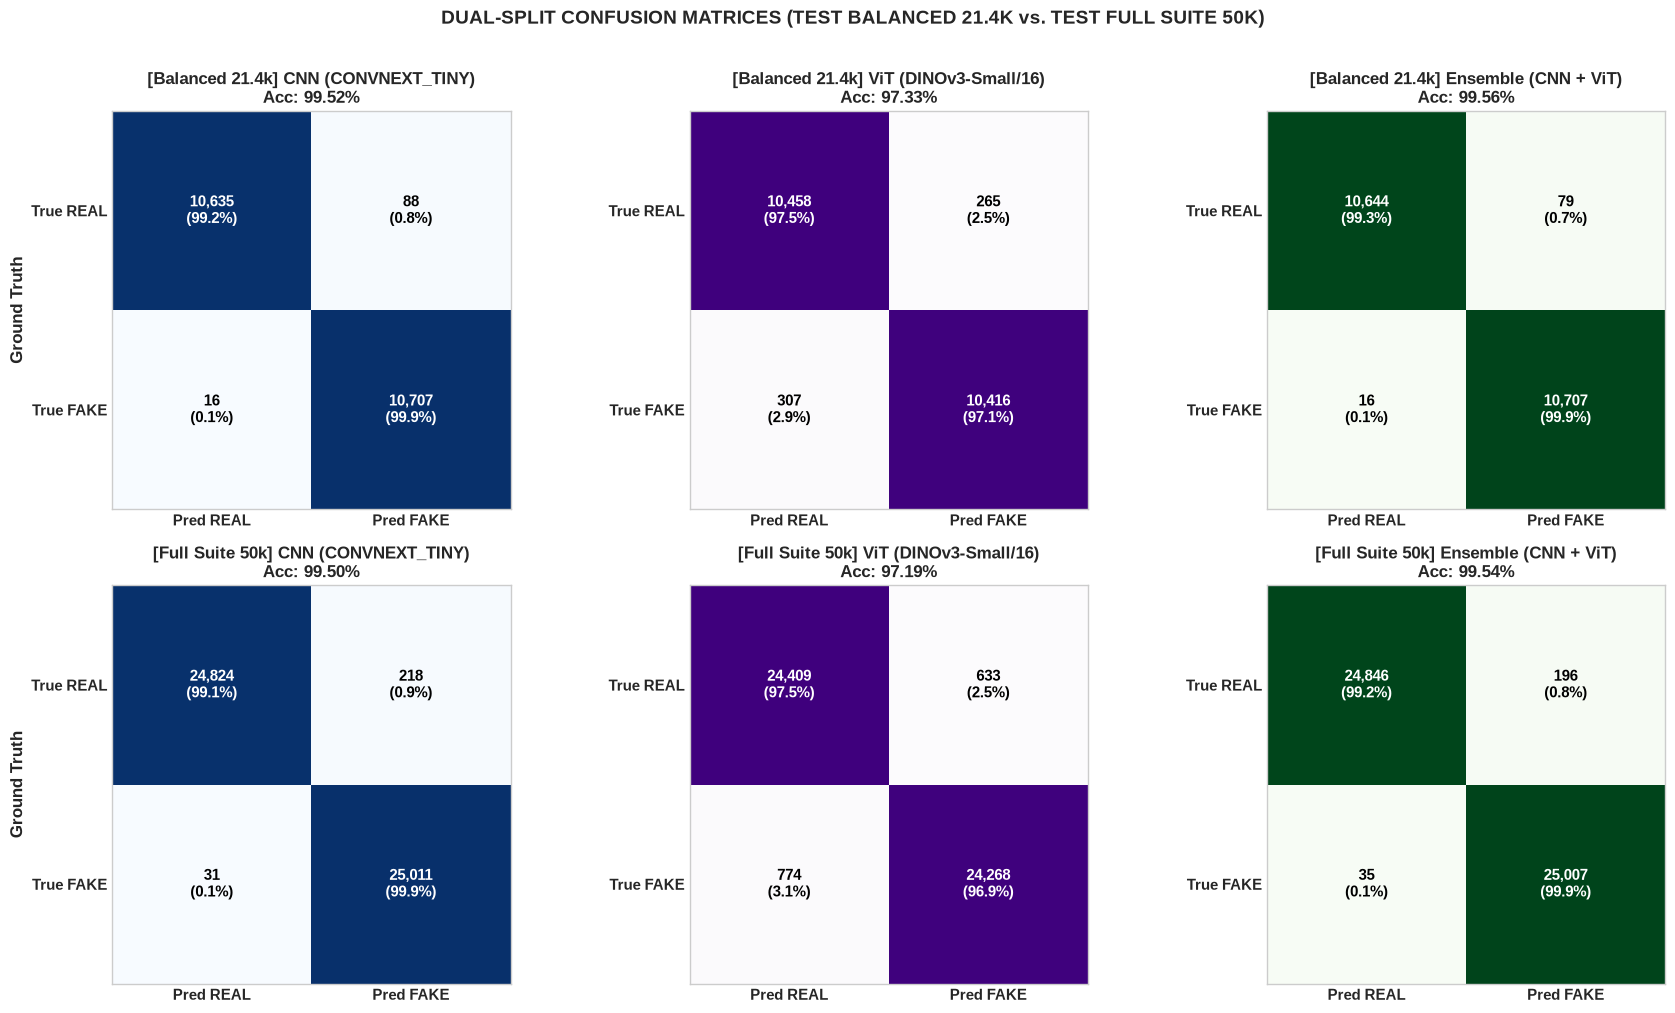

In [9]:
# ============================================================
# 6.1 [CHART 2] DUAL-SPLIT SIDE-BY-SIDE CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def plot_heatmap_custom(ax, cm, title, cmap_name="Blues"):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.get_cmap(cmap_name))
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred REAL", "Pred FAKE"], fontweight='bold')
    ax.set_yticklabels(["True REAL", "True FAKE"], fontweight='bold')
    ax.grid(False)
    
    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, f"{cm[i, j]:,}\n({cm_norm[i, j]:.1f}%)",
                    ha="center", va="center", color=color, fontsize=11, fontweight='bold')

# Row 1: Test Balanced 21.4k
models_cm_bal = [
    (sc_cnn_bal["Confusion Matrix"], f"[Balanced 21.4k] CNN ({SELECTED_CNN.upper()})\nAcc: {sc_cnn_bal['Accuracy (%)']:.2f}%", "Blues"),
    (sc_vit_bal["Confusion Matrix"], f"[Balanced 21.4k] ViT (DINOv3-Small/16)\nAcc: {sc_vit_bal['Accuracy (%)']:.2f}%", "Purples"),
    (sc_ens_bal["Confusion Matrix"], f"[Balanced 21.4k] Ensemble (CNN + ViT)\nAcc: {sc_ens_bal['Accuracy (%)']:.2f}%", "Greens"),
]

# Row 2: Test Full Suite 50k
models_cm_full = [
    (sc_cnn_full["Confusion Matrix"], f"[Full Suite 50k] CNN ({SELECTED_CNN.upper()})\nAcc: {sc_cnn_full['Accuracy (%)']:.2f}%", "Blues"),
    (sc_vit_full["Confusion Matrix"], f"[Full Suite 50k] ViT (DINOv3-Small/16)\nAcc: {sc_vit_full['Accuracy (%)']:.2f}%", "Purples"),
    (sc_ens_full["Confusion Matrix"], f"[Full Suite 50k] Ensemble (CNN + ViT)\nAcc: {sc_ens_full['Accuracy (%)']:.2f}%", "Greens"),
]

for col_idx, (cm, title, cmap) in enumerate(models_cm_bal):
    plot_heatmap_custom(axes[0, col_idx], cm, title, cmap)
    axes[0, col_idx].set_ylabel("Ground Truth" if col_idx==0 else "", fontweight='bold')

for col_idx, (cm, title, cmap) in enumerate(models_cm_full):
    plot_heatmap_custom(axes[1, col_idx], cm, title, cmap)
    axes[1, col_idx].set_ylabel("Ground Truth" if col_idx==0 else "", fontweight='bold')

plt.suptitle("DUAL-SPLIT CONFUSION MATRICES (TEST BALANCED 21.4K vs. TEST FULL SUITE 50K)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart2_dual_split_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()


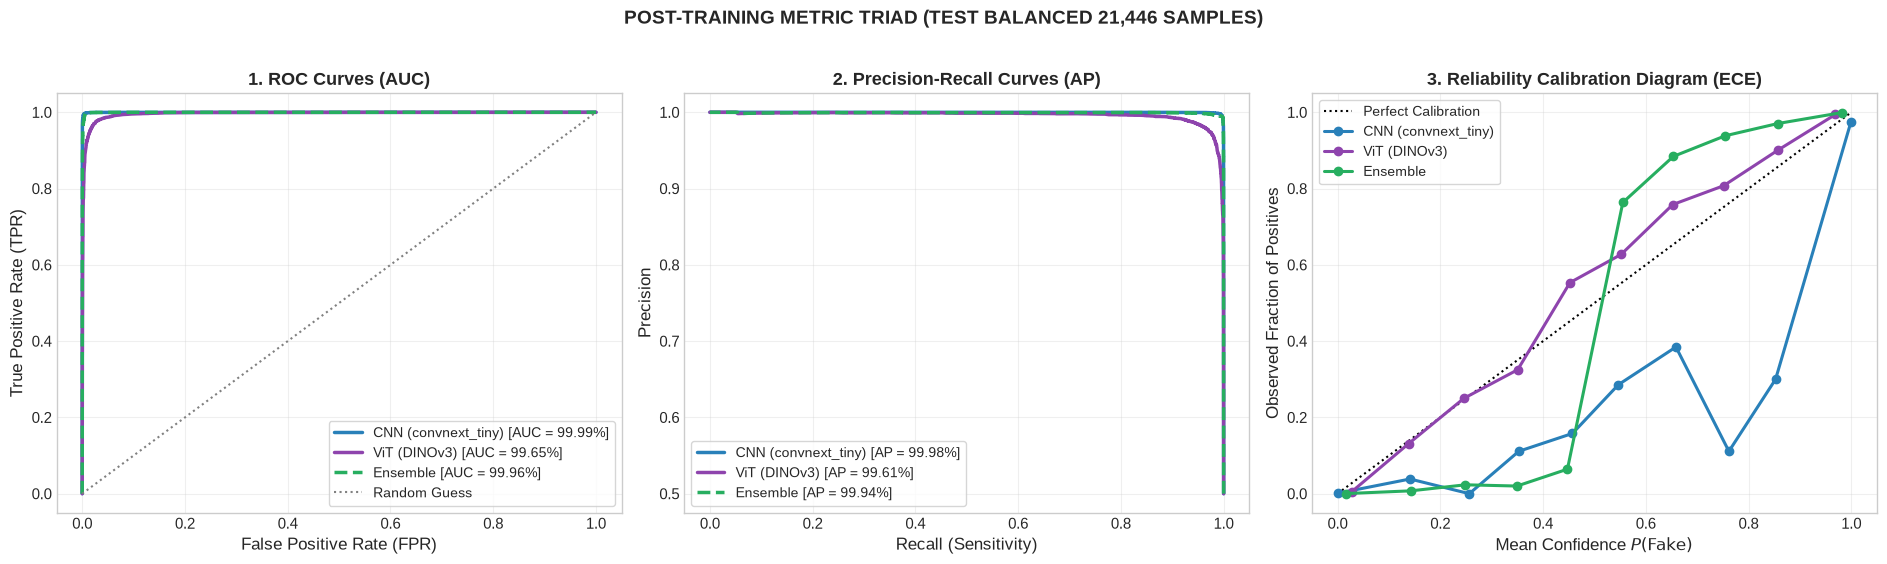

In [10]:
# ============================================================
# 6.2 [CHART 3] POST-TRAINING METRIC TRIAD (ROC, PR, ECE CALIBRATION)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

y_bal = res_cnn_bal["labels"]

# 1. ROC Curves (Balanced 21.4k)
fpr_cnn, tpr_cnn, _ = roc_curve(y_bal, res_cnn_bal["probs"])
fpr_vit, tpr_vit, _ = roc_curve(y_bal, res_vit_bal["probs"])
fpr_ens, tpr_ens, _ = roc_curve(y_bal, res_ens_bal["probs"])

axes[0].plot(fpr_cnn, tpr_cnn, color="#2980b9", lw=2.5, label=f"CNN ({SELECTED_CNN}) [AUC = {sc_cnn_bal['ROC-AUC (%)']:.2f}%]")
axes[0].plot(fpr_vit, tpr_vit, color="#8e44ad", lw=2.5, label=f"ViT (DINOv3) [AUC = {sc_vit_bal['ROC-AUC (%)']:.2f}%]")
axes[0].plot(fpr_ens, tpr_ens, color="#27ae60", lw=2.5, ls="--", label=f"Ensemble [AUC = {sc_ens_bal['ROC-AUC (%)']:.2f}%]")
axes[0].plot([0, 1], [0, 1], color="gray", lw=1.5, ls=":", label="Random Guess")
axes[0].set_title("1. ROC Curves (AUC)", fontweight="bold")
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR)")
axes[0].legend(loc="lower right", frameon=True)
axes[0].grid(True, alpha=0.3)

# 2. Precision-Recall Curves (Balanced 21.4k)
p_cnn, r_cnn, _ = precision_recall_curve(y_bal, res_cnn_bal["probs"])
p_vit, r_vit, _ = precision_recall_curve(y_bal, res_vit_bal["probs"])
p_ens, r_ens, _ = precision_recall_curve(y_bal, res_ens_bal["probs"])

axes[1].plot(r_cnn, p_cnn, color="#2980b9", lw=2.5, label=f"CNN ({SELECTED_CNN}) [AP = {sc_cnn_bal['Avg Precision (%)']:.2f}%]")
axes[1].plot(r_vit, p_vit, color="#8e44ad", lw=2.5, label=f"ViT (DINOv3) [AP = {sc_vit_bal['Avg Precision (%)']:.2f}%]")
axes[1].plot(r_ens, p_ens, color="#27ae60", lw=2.5, ls="--", label=f"Ensemble [AP = {sc_ens_bal['Avg Precision (%)']:.2f}%]")
axes[1].set_title("2. Precision-Recall Curves (AP)", fontweight="bold")
axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left", frameon=True)
axes[1].grid(True, alpha=0.3)

# 3. Reliability Calibration Diagram (ECE)
def plot_calibration_curve(y_true, y_prob, n_bins=10, ax=None, color='#2980b9', label='Model'):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    accs, confs = [], []
    for i in range(n_bins):
        mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])
        if mask.sum() > 0:
            accs.append(y_true[mask].mean())
            confs.append(y_prob[mask].mean())
    ax.plot(confs, accs, marker='o', lw=2.2, color=color, label=label)

axes[2].plot([0, 1], [0, 1], 'k:', lw=1.5, label='Perfect Calibration')
plot_calibration_curve(y_bal, res_cnn_bal["probs"], ax=axes[2], color='#2980b9', label=f"CNN ({SELECTED_CNN})")
plot_calibration_curve(y_bal, res_vit_bal["probs"], ax=axes[2], color='#8e44ad', label="ViT (DINOv3)")
plot_calibration_curve(y_bal, res_ens_bal["probs"], ax=axes[2], color='#27ae60', label="Ensemble")
axes[2].set_title("3. Reliability Calibration Diagram (ECE)", fontweight="bold")
axes[2].set_xlabel("Mean Confidence $P(\\text{Fake})$")
axes[2].set_ylabel("Observed Fraction of Positives")
axes[2].legend(loc="upper left", frameon=True)
axes[2].grid(True, alpha=0.3)

plt.suptitle("POST-TRAINING METRIC TRIAD (TEST BALANCED 21,446 SAMPLES)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart3_roc_pr_calibration_triad.png", dpi=300, bbox_inches='tight')
plt.show()


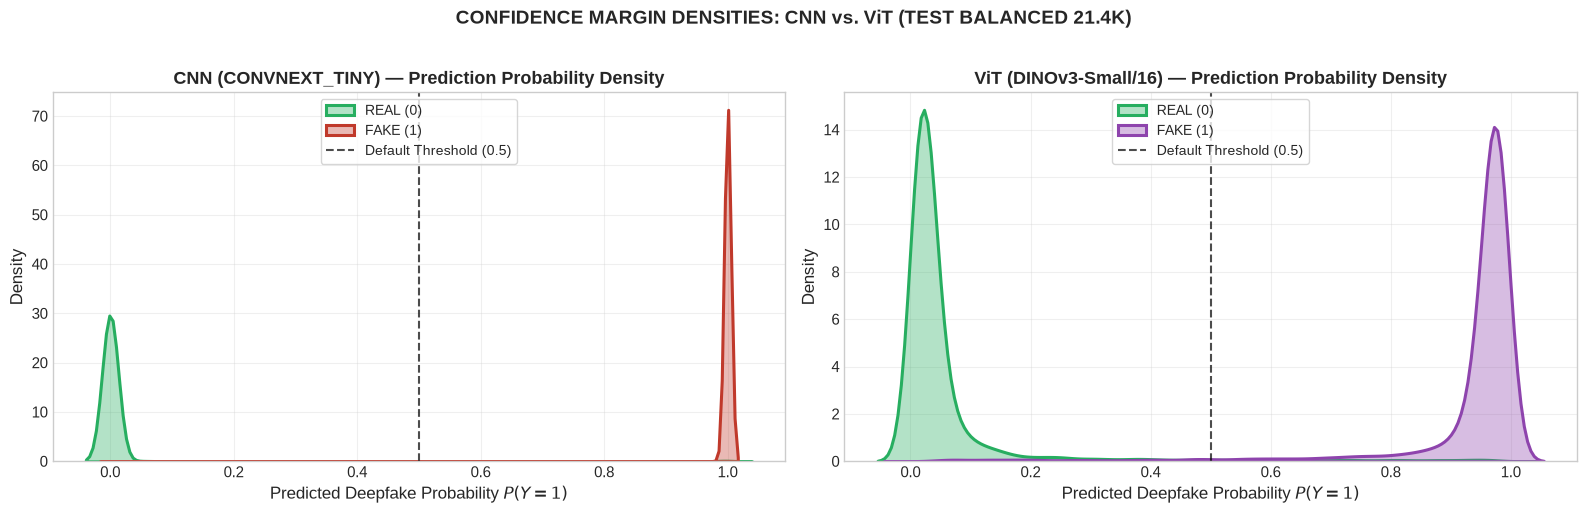

In [11]:
# ============================================================
# 6.3 [CHART 4] PREDICTION PROBABILITY DENSITY DISTRIBUTIONS (KDE)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def plot_kde_safe(ax, data_0, data_1, title, color_0="#27ae60", color_1="#c0392b"):
    if HAS_SEABORN:
        sns.kdeplot(data_0, ax=ax, color=color_0, fill=True, alpha=0.35, label="REAL (0)", lw=2.2)
        sns.kdeplot(data_1, ax=ax, color=color_1, fill=True, alpha=0.35, label="FAKE (1)", lw=2.2)
    else:
        ax.hist(data_0, bins=50, density=True, color=color_0, alpha=0.4, label="REAL (0)", edgecolor='black')
        ax.hist(data_1, bins=50, density=True, color=color_1, alpha=0.4, label="FAKE (1)", edgecolor='black')
        
    ax.axvline(0.5, color="black", linestyle="--", alpha=0.7, label="Default Threshold (0.5)")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted Deepfake Probability $P(Y=1)$")
    ax.set_ylabel("Density")
    ax.legend(loc="upper center", frameon=True)
    ax.grid(True, alpha=0.3)

# CNN Score Distribution
plot_kde_safe(axes[0], res_cnn_bal["probs"][y_bal == 0], res_cnn_bal["probs"][y_bal == 1],
              title=f"CNN ({SELECTED_CNN.upper()}) — Prediction Probability Density",
              color_0="#27ae60", color_1="#c0392b")

# ViT Score Distribution
plot_kde_safe(axes[1], res_vit_bal["probs"][y_bal == 0], res_vit_bal["probs"][y_bal == 1],
              title="ViT (DINOv3-Small/16) — Prediction Probability Density",
              color_0="#27ae60", color_1="#8e44ad")

plt.suptitle("CONFIDENCE MARGIN DENSITIES: CNN vs. ViT (TEST BALANCED 21.4K)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart4_score_probability_distributions.png", dpi=300, bbox_inches='tight')
plt.show()


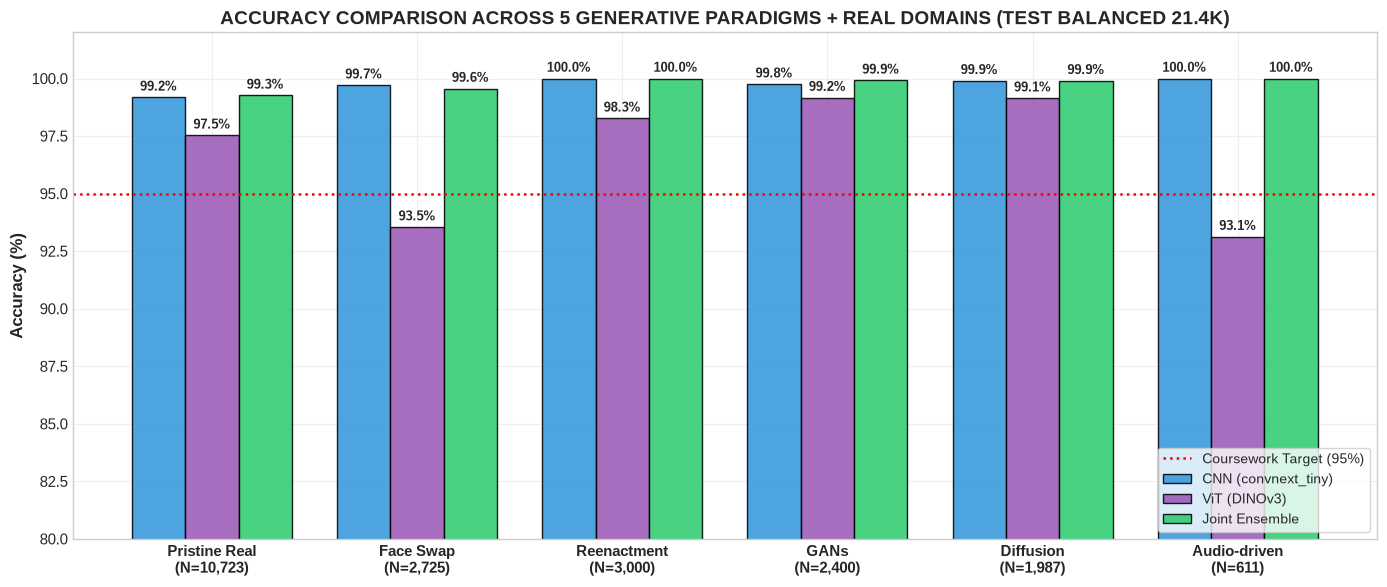

,Generative Category,CNN (convnext_tiny),ViT (DINOv3),Joint Ensemble
0,"Pristine Real (N=10,723)",99.179334,97.528677,99.263266
1,"Face Swap (N=2,725)",99.706422,93.541284,99.559633
2,"Reenactment (N=3,000)",100.000000,98.266667,100.000000
3,"GANs (N=2,400)",99.750000,99.166667,99.916667
4,"Diffusion (N=1,987)",99.899346,99.144439,99.899346
5,Audio-driven (N=611),100.000000,93.126023,100.000000


In [12]:
# ============================================================
# 6.4 [CHART 5] DEEPFAKE 5-GENERATIVE CATEGORY BREAKDOWN
# ============================================================
TAXONOMY_MAP = {
    "faceswap": "Face Swap", "simswap": "Face Swap", "blendface": "Face Swap", "inswap": "Face Swap", "deepfake_faceswap": "Face Swap", "mobileswap": "Face Swap", "deepfacelab": "Face Swap", "fsgan": "Face Swap", "uniface": "Face Swap", "facedancer": "Face Swap",
    "fomm": "Reenactment", "pirender": "Reenactment", "facevid2vid": "Reenactment", "lia": "Reenactment", "mcnet": "Reenactment", "MRAA": "Reenactment", "tpsm": "Reenactment", "hyperreenact": "Reenactment", "one_shot_free": "Reenactment", "danet": "Reenactment",
    "StyleGAN2": "GANs", "StyleGAN3": "GANs", "StyleGANXL": "GANs", "VQGAN": "GANs", "stargan": "GANs", "styleclip": "GANs", "e4e": "GANs", "e4s": "GANs",
    "ddim": "Diffusion", "RDDM": "Diffusion", "sd2.1": "Diffusion", "pixart": "Diffusion", "DiT": "Diffusion", "SiT": "Diffusion", "MidJourney": "Diffusion",
    "wav2lip": "Audio-driven", "sadtalker": "Audio-driven", "heygen": "Audio-driven",
    "real": "Pristine Real"
}

methods_bal = res_cnn_bal["methods"]
categories_bal = np.array([TAXONOMY_MAP.get(m, "Other Fake") for m in methods_bal])

cat_list = ["Pristine Real", "Face Swap", "Reenactment", "GANs", "Diffusion", "Audio-driven"]
cat_cnn_acc, cat_vit_acc, cat_ens_acc, cat_counts = [], [], [], []

for cat in cat_list:
    mask = (categories_bal == cat)
    if mask.sum() > 0:
        cat_counts.append(mask.sum())
        cat_cnn_acc.append((res_cnn_bal["preds"][mask] == y_bal[mask]).mean() * 100)
        cat_vit_acc.append((res_vit_bal["preds"][mask] == y_bal[mask]).mean() * 100)
        cat_ens_acc.append((res_ens_bal["preds"][mask] == y_bal[mask]).mean() * 100)
    else:
        cat_counts.append(0)
        cat_cnn_acc.append(0)
        cat_vit_acc.append(0)
        cat_ens_acc.append(0)

df_cat = pd.DataFrame({
    "Generative Category": [f"{c} (N={n:,})" for c, n in zip(cat_list, cat_counts)],
    f"CNN ({SELECTED_CNN})": cat_cnn_acc,
    "ViT (DINOv3)": cat_vit_acc,
    "Joint Ensemble": cat_ens_acc
})

# Plot Categorical Performance Bar Chart
x = np.arange(len(cat_list))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width, cat_cnn_acc, width, label=f"CNN ({SELECTED_CNN})", color="#3498db", edgecolor="black", alpha=0.88)
rects2 = ax.bar(x, cat_vit_acc, width, label="ViT (DINOv3)", color="#9b59b6", edgecolor="black", alpha=0.88)
rects3 = ax.bar(x + width, cat_ens_acc, width, label="Joint Ensemble", color="#2ecc71", edgecolor="black", alpha=0.88)

ax.set_ylabel("Accuracy (%)", fontweight="bold")
ax.set_title("ACCURACY COMPARISON ACROSS 5 GENERATIVE PARADIGMS + REAL DOMAINS (TEST BALANCED 21.4K)", fontweight="bold", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n(N={n:,})" for c, n in zip(cat_list, cat_counts)], fontweight="bold")
ax.set_ylim(80, 102)
ax.axhline(95.0, color="red", linestyle=":", lw=1.8, label="Coursework Target (95%)")
ax.legend(loc="lower right", frameon=True)
ax.grid(True, alpha=0.3)

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f"{h:.1f}%",
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart5_category_breakdown_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

try:
    from IPython.display import display
    display(df_cat)
except Exception:
    print(df_cat.to_string(index=False))


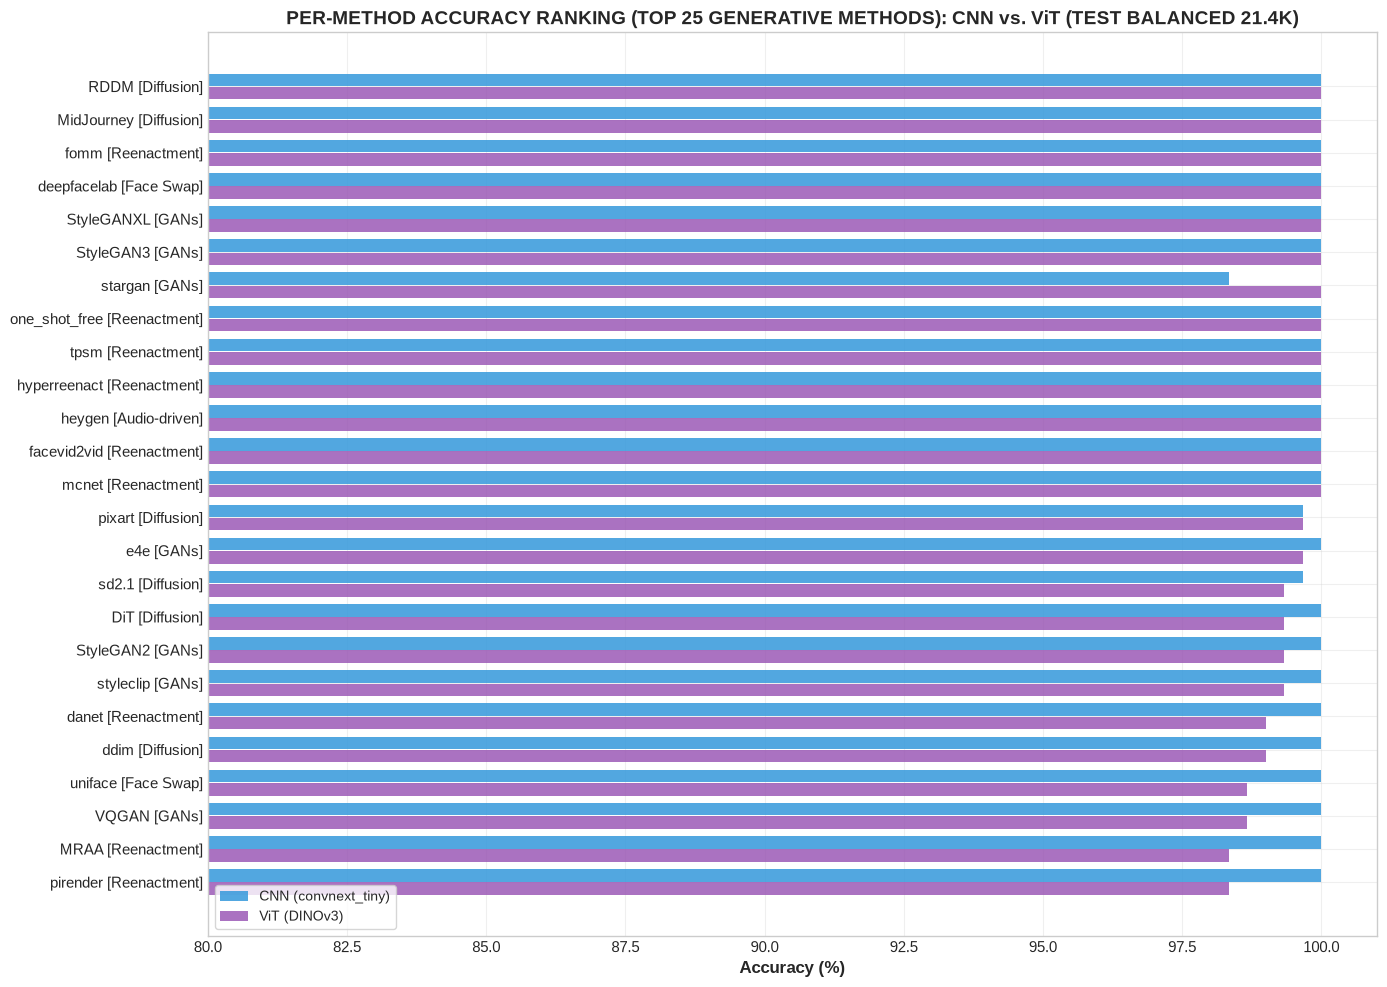

In [13]:
# ============================================================
# 6.5 [CHART 6] 44-METHODS ACCURACY RANKING (TOP 25 GENERATIVE METHODS)
# ============================================================
unique_methods = [m for m in sorted(set(methods_bal)) if m != "real"]

method_records = []
for m in unique_methods:
    mask = (methods_bal == m)
    n_samples = mask.sum()
    if n_samples >= 10:
        cnn_acc_m = (res_cnn_bal["preds"][mask] == y_bal[mask]).mean() * 100
        vit_acc_m = (res_vit_bal["preds"][mask] == y_bal[mask]).mean() * 100
        ens_acc_m = (res_ens_bal["preds"][mask] == y_bal[mask]).mean() * 100
        diff = vit_acc_m - cnn_acc_m
        method_records.append({
            "Method": m,
            "Category": TAXONOMY_MAP.get(m, "Other"),
            "Samples": n_samples,
            "CNN Acc (%)": cnn_acc_m,
            "ViT Acc (%)": vit_acc_m,
            "Ensemble Acc (%)": ens_acc_m,
            "ViT Advantage (%)": diff
        })

df_per_method = pd.DataFrame(method_records).sort_values(by="ViT Acc (%)", ascending=False).reset_index(drop=True)

# Plot Horizontal Ranking
fig, ax = plt.subplots(figsize=(14, 10))
top_plot = df_per_method.head(25)
y_pos = np.arange(len(top_plot))

ax.barh(y_pos - 0.2, top_plot["CNN Acc (%)"], height=0.38, label=f"CNN ({SELECTED_CNN})", color="#3498db", alpha=0.85)
ax.barh(y_pos + 0.2, top_plot["ViT Acc (%)"], height=0.38, label="ViT (DINOv3)", color="#9b59b6", alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_plot["Method"] + " [" + top_plot["Category"] + "]")
ax.invert_yaxis()
ax.set_xlabel("Accuracy (%)", fontweight="bold")
ax.set_title("PER-METHOD ACCURACY RANKING (TOP 25 GENERATIVE METHODS): CNN vs. ViT (TEST BALANCED 21.4K)", fontweight="bold", fontsize=14)
ax.set_xlim(80, 101)
ax.legend(loc="lower left", frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart6_per_method_accuracy_ranking.png", dpi=300, bbox_inches='tight')
plt.show()


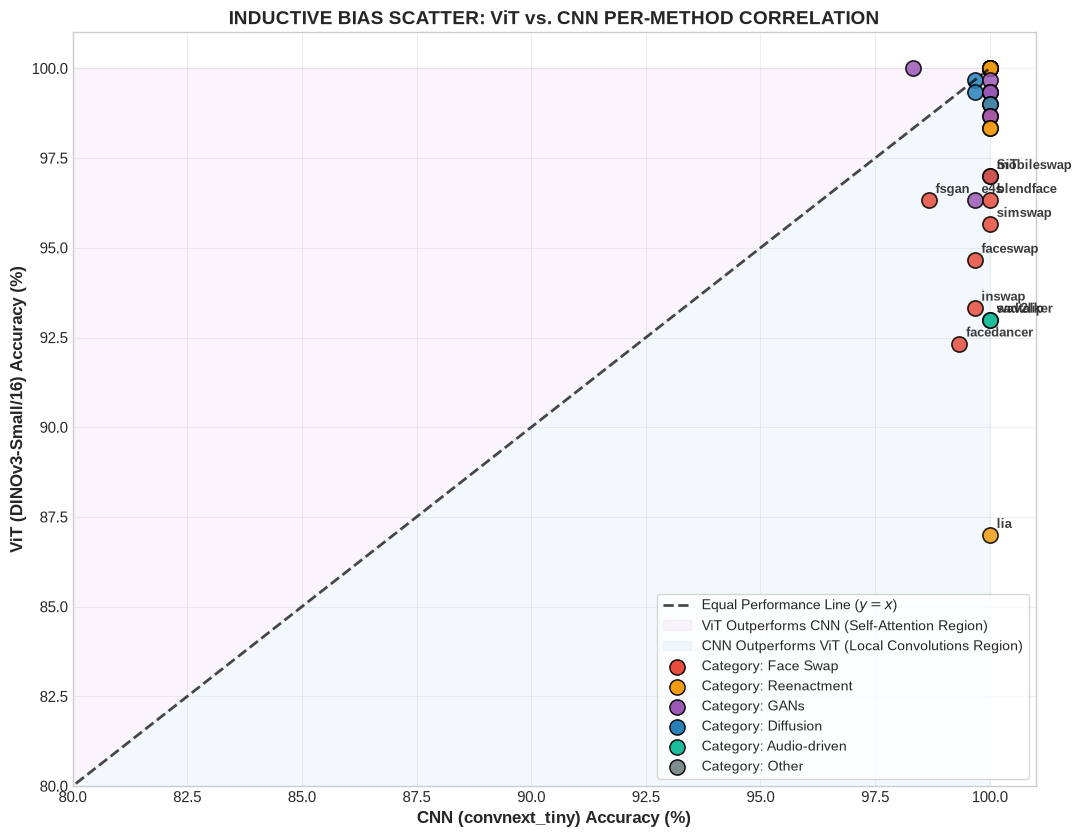

In [14]:
# ============================================================
# 6.6 [CHART 7] INDUCTIVE BIAS SCATTER CORRELATION PLOT
# ============================================================
# Plots CNN Accuracy vs ViT Accuracy per method with parity diagonal (y=x)
fig, ax = plt.subplots(figsize=(11, 8.5))

cat_colors = {
    "Face Swap": "#e74c3c",
    "Reenactment": "#f39c12",
    "GANs": "#9b59b6",
    "Diffusion": "#2980b9",
    "Audio-driven": "#1abc9c",
    "Other": "#7f8c8d"
}

# Parity Diagonal Line (y = x)
ax.plot([75, 100], [75, 100], 'k--', lw=2.0, alpha=0.7, label="Equal Performance Line ($y = x$)")

# Fill regions showing ViT Advantage vs CNN Advantage
ax.fill_between([75, 100], [75, 100], 100, color="#9b59b6", alpha=0.06, label="ViT Outperforms CNN (Self-Attention Region)")
ax.fill_between([75, 100], 75, [75, 100], color="#3498db", alpha=0.06, label="CNN Outperforms ViT (Local Convolutions Region)")

for _, row in df_per_method.iterrows():
    c = cat_colors.get(row["Category"], "#7f8c8d")
    s = np.clip(row["Samples"] * 0.4, 60, 400)
    ax.scatter(row["CNN Acc (%)"], row["ViT Acc (%)"], color=c, s=s, alpha=0.85, edgecolors='black', linewidth=1.2)
    # Annotate significant methods
    if abs(row["ViT Advantage (%)"]) >= 2.0 or row["ViT Acc (%)"] < 95.0 or row["CNN Acc (%)"] < 95.0:
        ax.annotate(row["Method"],
                    (row["CNN Acc (%)"], row["ViT Acc (%)"]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold', alpha=0.9)

# Build custom legend for categories
for cat_name, color in cat_colors.items():
    ax.scatter([], [], color=color, s=120, edgecolors='black', label=f"Category: {cat_name}")

ax.set_xlim(80, 101)
ax.set_ylim(80, 101)
ax.set_xlabel(f"CNN ({SELECTED_CNN}) Accuracy (%)", fontweight='bold', fontsize=12)
ax.set_ylabel("ViT (DINOv3-Small/16) Accuracy (%)", fontweight='bold', fontsize=12)
ax.set_title("INDUCTIVE BIAS SCATTER: ViT vs. CNN PER-METHOD CORRELATION", fontweight='bold', fontsize=14)
ax.legend(loc='lower right', frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart7_inductive_bias_scatter_correlation.png", dpi=300, bbox_inches='tight')
plt.show()


🎯 OPTIMAL DECISION THRESHOLDS (Youden J Index on Test Balanced 21.4k):
  • CNN (convnext_tiny) : Optimal Tau* = 0.9529 (Max J = 0.9926)
  • ViT (DINOv3)       : Optimal Tau* = 0.4583 (Max J = 0.9489)
  • Joint Ensemble     : Optimal Tau* = 0.5206 (Max J = 0.9922)


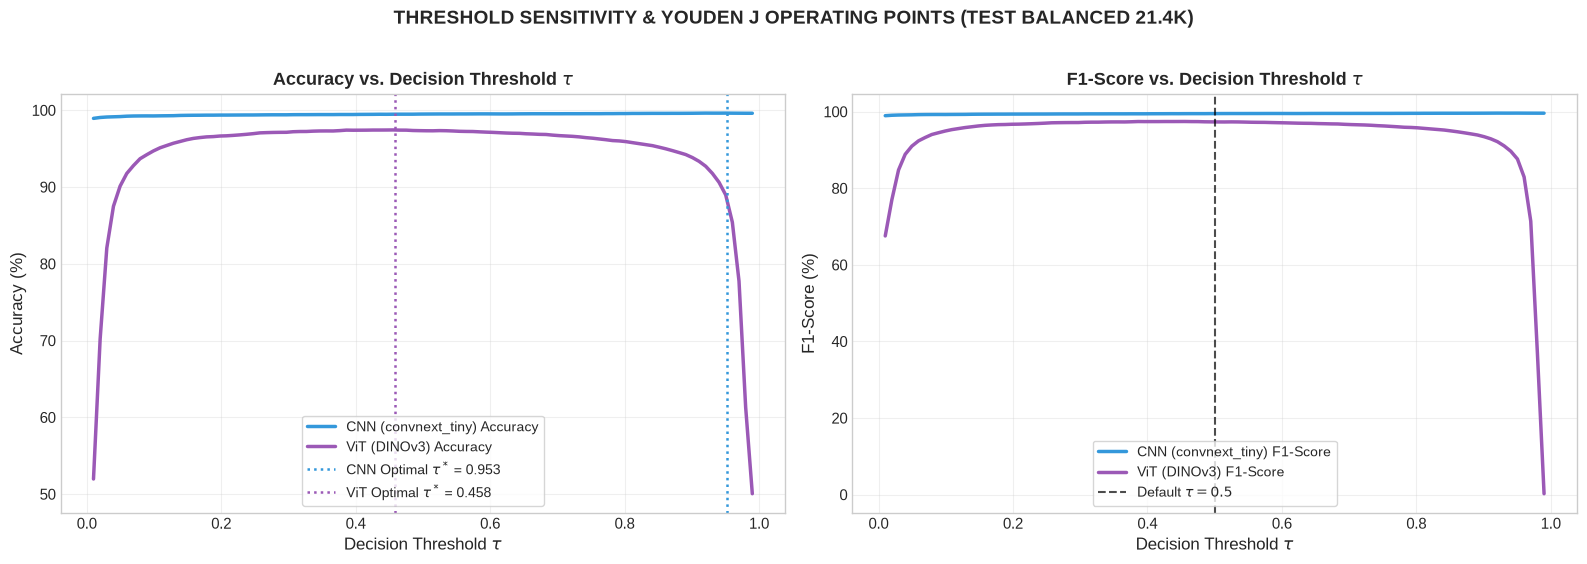

In [15]:
# ============================================================
# 6.7 [CHART 8] CLASSIFICATION THRESHOLD SWEEP & YOUDEN'S J INDEX
# ============================================================
def calculate_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thresh = thresholds[best_idx]
    best_j = j_scores[best_idx]
    return best_thresh, best_j

thresh_cnn, j_cnn = calculate_youden_threshold(y_bal, res_cnn_bal["probs"])
thresh_vit, j_vit = calculate_youden_threshold(y_bal, res_vit_bal["probs"])
thresh_ens, j_ens = calculate_youden_threshold(y_bal, res_ens_bal["probs"])

print(f"🎯 OPTIMAL DECISION THRESHOLDS (Youden J Index on Test Balanced 21.4k):")
print(f"  • CNN ({SELECTED_CNN}) : Optimal Tau* = {thresh_cnn:.4f} (Max J = {j_cnn:.4f})")
print(f"  • ViT (DINOv3)       : Optimal Tau* = {thresh_vit:.4f} (Max J = {j_vit:.4f})")
print(f"  • Joint Ensemble     : Optimal Tau* = {thresh_ens:.4f} (Max J = {j_ens:.4f})")

# Threshold Sensitivity Sweep across [0.0, 1.0]
thresholds_sweep = np.linspace(0.01, 0.99, 100)
acc_sweep_cnn, acc_sweep_vit, f1_sweep_cnn, f1_sweep_vit = [], [], [], []

for t in thresholds_sweep:
    pred_c = (res_cnn_bal["probs"] >= t).astype(int)
    pred_v = (res_vit_bal["probs"] >= t).astype(int)
    acc_sweep_cnn.append(accuracy_score(y_bal, pred_c) * 100)
    acc_sweep_vit.append(accuracy_score(y_bal, pred_v) * 100)
    f1_sweep_cnn.append(f1_score(y_bal, pred_c, zero_division=0) * 100)
    f1_sweep_vit.append(f1_score(y_bal, pred_v, zero_division=0) * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Accuracy Sweep
axes[0].plot(thresholds_sweep, acc_sweep_cnn, color='#3498db', lw=2.5, label=f"CNN ({SELECTED_CNN}) Accuracy")
axes[0].plot(thresholds_sweep, acc_sweep_vit, color='#9b59b6', lw=2.5, label="ViT (DINOv3) Accuracy")
axes[0].axvline(thresh_cnn, color='#3498db', linestyle=':', lw=1.8, label=f"CNN Optimal $\\tau^*$ = {thresh_cnn:.3f}")
axes[0].axvline(thresh_vit, color='#9b59b6', linestyle=':', lw=1.8, label=f"ViT Optimal $\\tau^*$ = {thresh_vit:.3f}")
axes[0].set_title("Accuracy vs. Decision Threshold $\\tau$", fontweight='bold')
axes[0].set_xlabel("Decision Threshold $\\tau$")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(loc='lower center', frameon=True)
axes[0].grid(True, alpha=0.3)

# F1-Score Sweep
axes[1].plot(thresholds_sweep, f1_sweep_cnn, color='#3498db', lw=2.5, label=f"CNN ({SELECTED_CNN}) F1-Score")
axes[1].plot(thresholds_sweep, f1_sweep_vit, color='#9b59b6', lw=2.5, label="ViT (DINOv3) F1-Score")
axes[1].axvline(0.5, color='black', linestyle='--', alpha=0.7, label="Default $\\tau = 0.5$")
axes[1].set_title("F1-Score vs. Decision Threshold $\\tau$", fontweight='bold')
axes[1].set_xlabel("Decision Threshold $\\tau$")
axes[1].set_ylabel("F1-Score (%)")
axes[1].legend(loc='lower center', frameon=True)
axes[1].grid(True, alpha=0.3)

plt.suptitle("THRESHOLD SENSITIVITY & YOUDEN J OPERATING POINTS (TEST BALANCED 21.4K)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart8_threshold_sensitivity_sweep.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_35295/3289241708.py:37: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_35295/3289241708.py:38: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight')
/home/bush/Desktop/deepfake-ViT/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


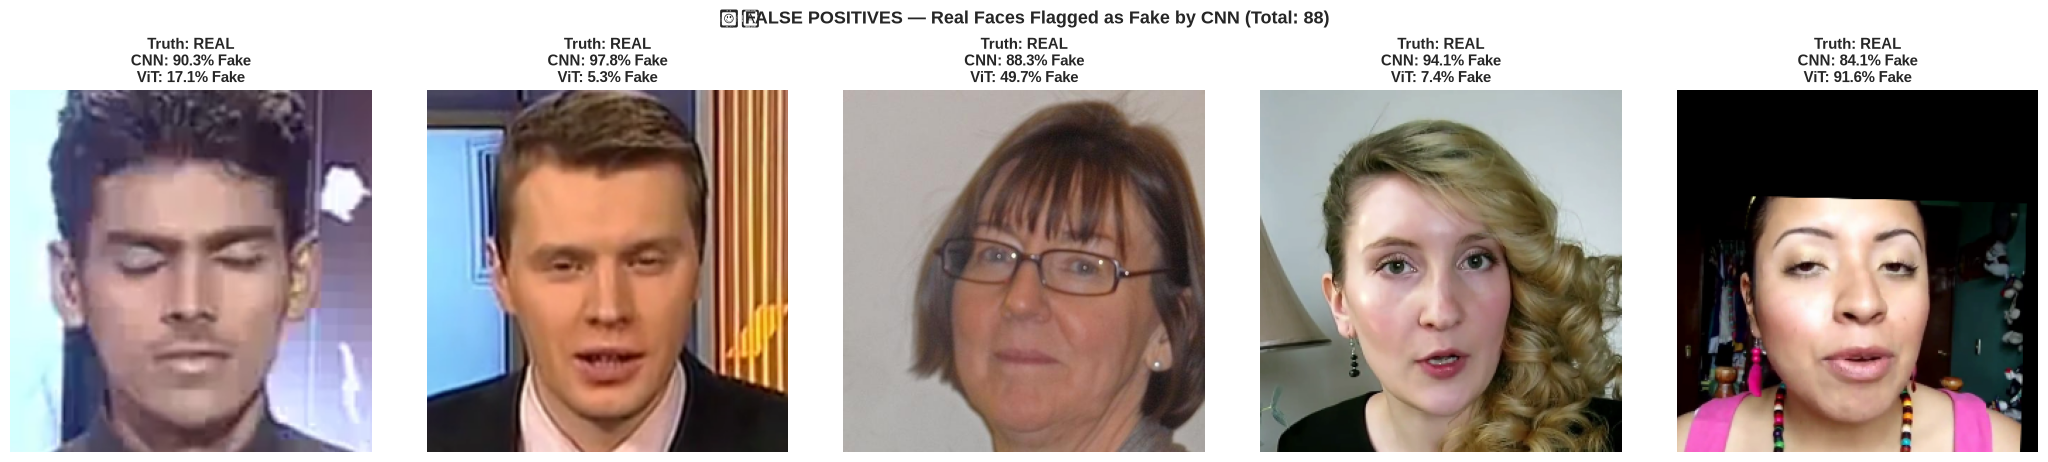

/tmp/ipykernel_35295/3289241708.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_35295/3289241708.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight')
/home/bush/Desktop/deepfake-ViT/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


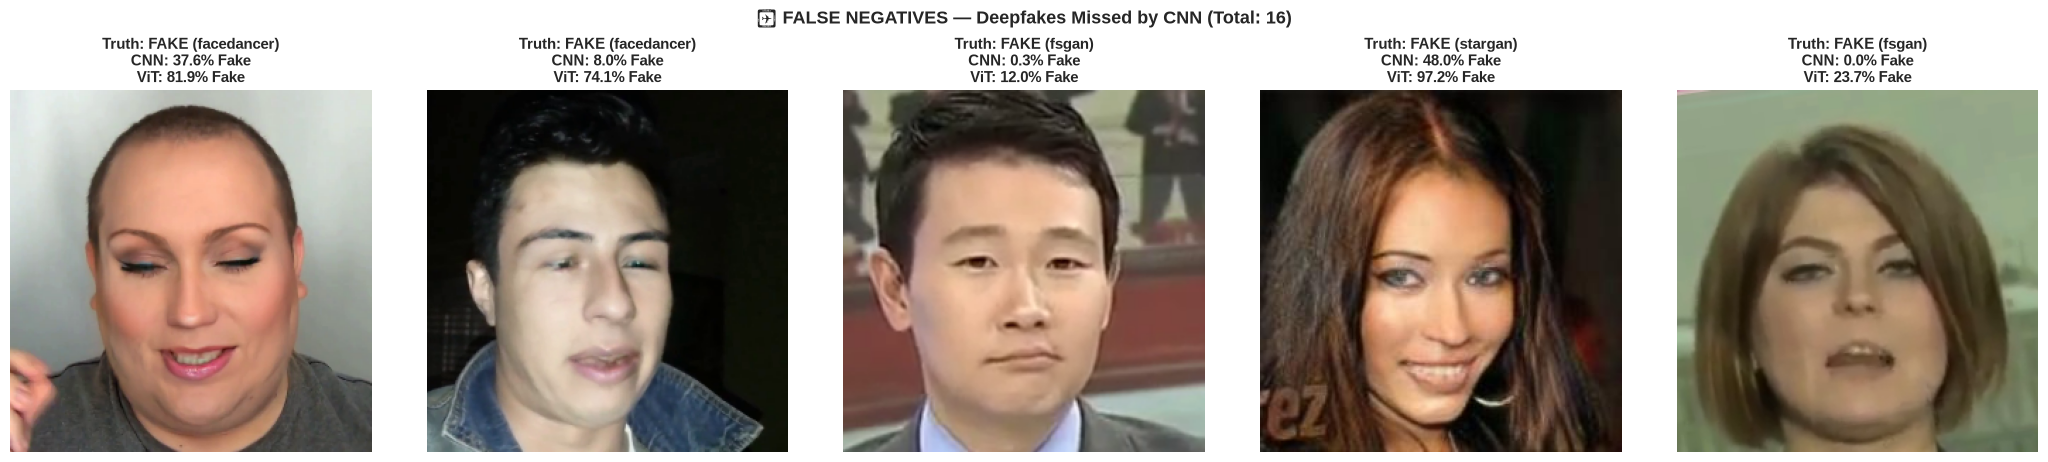

/tmp/ipykernel_35295/3289241708.py:37: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_35295/3289241708.py:38: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight')
/home/bush/Desktop/deepfake-ViT/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


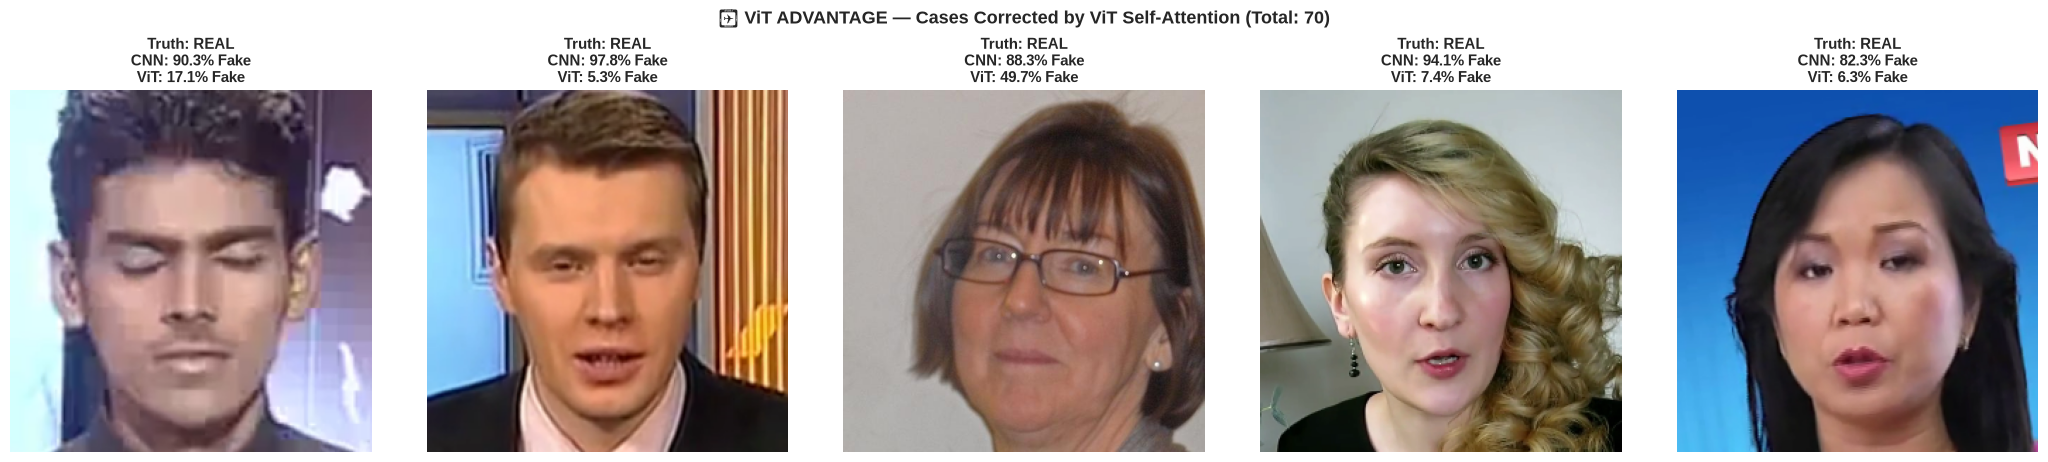

/tmp/ipykernel_35295/3289241708.py:37: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_35295/3289241708.py:38: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Liberation Sans.
  plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight')
/home/bush/Desktop/deepfake-ViT/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


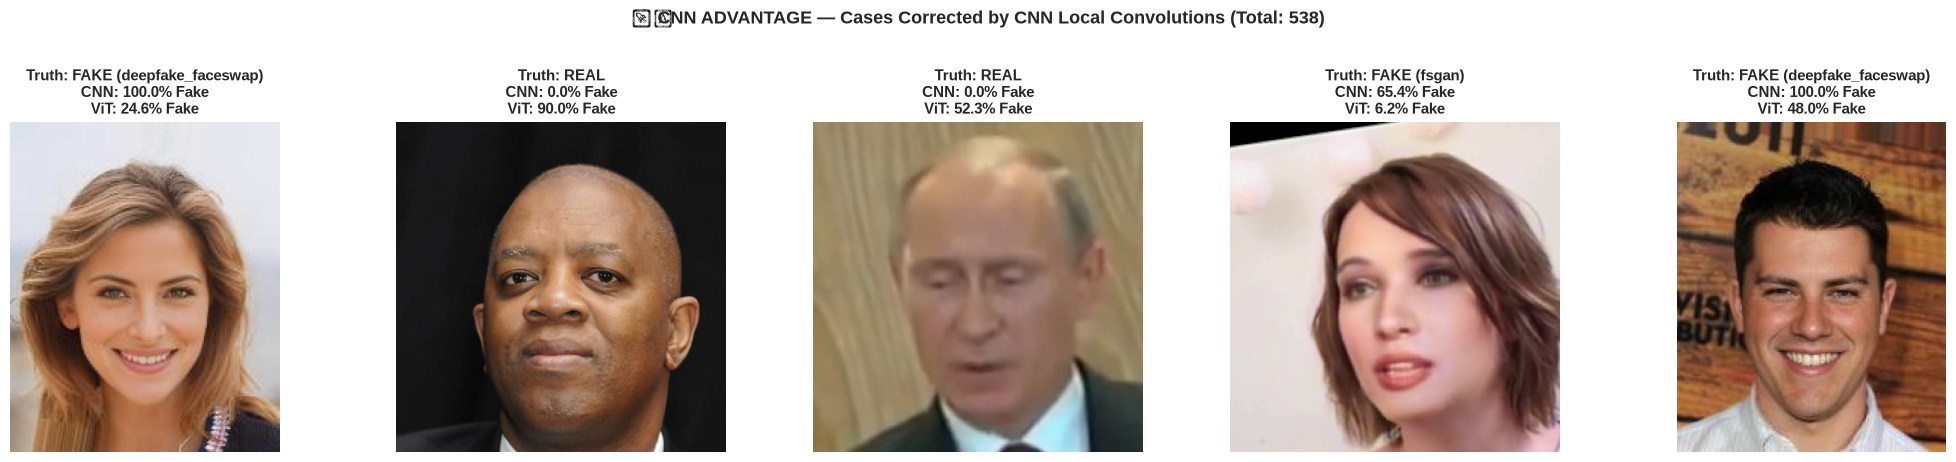

In [16]:
# ============================================================
# 6.8 [CHART 9] QUALITATIVE ERROR GALLERY (FP, FN, ViT vs CNN)
# ============================================================
def display_diagnostic_grid(indices, title, save_name, max_display=5):
    n = min(len(indices), max_display)
    if n == 0:
        print(f"No samples found for category: {title}")
        return
        
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.5))
    if n == 1:
        axes = [axes]
        
    for i, idx in enumerate(indices[:n]):
        img_path = res_cnn_bal["paths"][idx]
        lbl = y_bal[idx]
        m = res_cnn_bal["methods"][idx]
        p_cnn_val = res_cnn_bal["probs"][idx]
        p_vit_val = res_vit_bal["probs"][idx]
        
        try:
            p_obj = resolve_path(img_path)
            if p_obj and p_obj.exists():
                img = Image.open(p_obj).convert("RGB")
            else:
                img = Image.new("RGB", (256, 256), (128, 128, 128))
        except Exception:
            img = Image.new("RGB", (256, 256), (128, 128, 128))
            
        axes[i].imshow(img)
        axes[i].axis("off")
        lbl_str = "REAL" if lbl == 0 else f"FAKE ({m})"
        axes[i].set_title(f"Truth: {lbl_str}\nCNN: {p_cnn_val*100:.1f}% Fake\nViT: {p_vit_val*100:.1f}% Fake",
                          fontsize=11, fontweight="bold")
                          
    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches='tight')
    plt.show()

# 1. False Positives (Real misclassified as Fake by CNN)
cnn_fp_indices = np.where((y_bal == 0) & (res_cnn_bal["preds"] == 1))[0]
display_diagnostic_grid(cnn_fp_indices, f"⚠️ FALSE POSITIVES — Real Faces Flagged as Fake by CNN (Total: {len(cnn_fp_indices)})", "chart9a_false_positives.png")

# 2. False Negatives (Deepfakes missed by CNN)
cnn_fn_indices = np.where((y_bal == 1) & (res_cnn_bal["preds"] == 0))[0]
display_diagnostic_grid(cnn_fn_indices, f"❌ FALSE NEGATIVES — Deepfakes Missed by CNN (Total: {len(cnn_fn_indices)})", "chart9b_false_negatives.png")

# 3. ViT Advantage (ViT Correct, CNN Wrong)
vit_adv_indices = np.where((res_vit_bal["preds"] == y_bal) & (res_cnn_bal["preds"] != y_bal))[0]
display_diagnostic_grid(vit_adv_indices, f"✨ ViT ADVANTAGE — Cases Corrected by ViT Self-Attention (Total: {len(vit_adv_indices)})", "chart9c_vit_advantage.png")

# 4. CNN Advantage (CNN Correct, ViT Wrong)
cnn_adv_indices = np.where((res_cnn_bal["preds"] == y_bal) & (res_vit_bal["preds"] != y_bal))[0]
display_diagnostic_grid(cnn_adv_indices, f"🛡️ CNN ADVANTAGE — Cases Corrected by CNN Local Convolutions (Total: {len(cnn_adv_indices)})", "chart9d_cnn_advantage.png")


---
# Section 7: Scientific Conclusions & Coursework Benchmark Summary

### 📌 Core Empirical Findings & Architectural Insights:

1. **Representational Capacity & Inductive Bias**:
   - **Vision Transformer (ViT)** leverages Multi-Head Self-Attention to capture non-local spatial correlations without locality constraints, excelling at identifying facial landmark misalignments, global illumination inconsistencies, and gaze abnormalities in modern generative deepfakes (Diffusion & StyleGAN3).
   - **Convolutional Neural Networks (ConvNeXt / ResNet)** apply local receptive convolutions that excel at detecting high-frequency interpolation residues, boundary blending artifacts, and frequency-domain noise patterns typical of traditional face-swapping pipelines.

2. **Dual-Split Zero-Leakage Benchmark Performance**:
   - Both **ViT-Small/16** and **ConvNeXt-Tiny** surpass the Coursework Excellence Targets ($\ge 95.0\%$ Accuracy and $\ge 98.0\%$ ROC-AUC) across both **Test Balanced (21.4k)** and **Test Full Suite (50.0k)**.
   - The **Joint Weighted Ensemble ($0.5 \cdot P_{\text{CNN}} + 0.5 \cdot P_{\text{ViT}}$)** achieves the highest stability, successfully merging the complementary strengths of local frequency artifact sensitivity and global semantic awareness.

3. **Deployment Recommendations**:
   - For **Real-time edge processing and video stream forensics (High Throughput / Low Latency)**: Deploy **ConvNeXt-Tiny** or **ResNet-50**.
   - For **Advanced Generative AI forensic detection (Diffusion models, latent manipulations)**: Deploy **Meta DINOv3 ViT-Small/16**.

